# VLSI Physical Design — Advanced GNN on CircuitNet ISPD15
# Optimized Pipeline for Industrial-Scale Placement Prediction

## Dataset: CircuitNet ISPD15 (533 samples, 14 chip designs)

### Chip Designs in this Dataset:
| Design | Type | Cells | Samples |
|--------|------|-------|---------|
| mgc_pci_bridge32_a/b | PCI Bridge | ~29K | 72 |
| mgc_fft_a/b | FFT Processor | ~30K | 88 |
| mgc_edit_dist_a | Edit Distance | ~127K | 45 |
| mgc_des_perf_a | DES Encrypt | ~108K | 45 |
| mgc_matrix_mult_a/b/c | Matrix Multiplier | varied | 133 |
| mgc_superblue11_a | Industrial SoC | ~927K | 30 |
| mgc_superblue12 | Industrial SoC | ~1.29M | 30 |
| mgc_superblue14 | Industrial SoC | ~609K | 30 |
| mgc_superblue16_a | Industrial SoC | ~681K | 30 |
| mgc_superblue19 | Industrial SoC | ~506K | 30 |

### Data Available Per Sample:
- **Instance placement** (micron coords): cell_name → [x_min, y_min, x_max, y_max]
- **Graph features**: node_attr (cell names + types), net_attr, pin_attr (connectivity)
- **Routability features**: cell_density, macro_map, congestion, net_density, RUDY
- **DEF files**: Full placement definitions (gzipped)

### Pipeline:
1. Setup & Installation
2. Data Loading (ISPD15-specific paths)
3. Advanced GNN Architecture (GraphSAGE + GAT + Transformer)
4. Industry-Aware Training with Multi-Component Loss
5. Evaluation, Legalization & Visualization
6. Export (DEF, JSON)

---

# STEP 1: Setup & Installation

Install all required packages for VLSI physical design with ML.

In [1]:
# Install PyTorch first (CUDA 11.8)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 

# Install PyTorch Geometric and extensions using pre-built wheels
!pip install torch-geometric 
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.7.0+cu118.html 

# Install other utilities
!pip install matplotlib numpy scipy pandas psutil 

print("All packages installed successfully!")

Looking in indexes: https://download.pytorch.org/whl/cu118



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in links: https://data.pyg.org/whl/torch-2.7.0+cu118.html



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


All packages installed successfully!



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---

# STEP 2: Import Libraries

Import all necessary libraries for the pipeline.

In [2]:
# Core libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# PyTorch Geometric
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, GCNConv
from torch_geometric.loader import DataLoader

# Numerical and visualization
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Rectangle

# System utilities
import os
import time
import gc
import psutil
from scipy.spatial import KDTree
from collections import defaultdict, Counter

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"   PyTorch version: {torch.__version__}")

if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

print("\nAll libraries imported successfully!")

c:\Users\Admin\VLSI-\Ayush\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
   PyTorch version: 2.7.1+cu118
   GPU: NVIDIA GeForce RTX 4060
   GPU Memory: 8.59 GB

All libraries imported successfully!


---

# STEP 3: Configure Paths

Set up paths to your CircuitNet dataset.

In [3]:
# ============================================
# CONFIGURE PATHS FOR CIRCUITNET ISPD15
# ============================================

CIRCUITNET_BASE = r"C:\Users\Admin\VLSI-\Ayush\CircuitNet-ISPD15-20260306T084027Z-3-004"
model_save = r"C:\Users\Admin\VLSI-\Ayush\ispd15_placement_model.pth"
output_dir = r"C:\Users\Admin\VLSI-\Ayush\vlsi_results_ispd15"

# ISPD15 dataset paths (different structure from previous CircuitNet)
PLACEMENT_PATH = os.path.join(CIRCUITNET_BASE, "instance_placement_micron", "instance_placement_micron")
NODE_ATTR_PATH = os.path.join(CIRCUITNET_BASE, "graph_infromation", "graph_infromation", "node_attr")
NET_ATTR_PATH  = os.path.join(CIRCUITNET_BASE, "graph_infromation", "graph_infromation", "net_attr")
PIN_ATTR_PATH  = os.path.join(CIRCUITNET_BASE, "graph_infromation", "graph_infromation", "pin_attr")
CELL_DENSITY_PATH = os.path.join(CIRCUITNET_BASE, "routability_features", "routability_features", "cell_density")
MACRO_MAP_PATH = os.path.join(CIRCUITNET_BASE, "routability_features", "routability_features", "macro_map")

os.makedirs(output_dir, exist_ok=True)

# Verify all paths
print("Verifying ISPD15 dataset paths...\n")
paths_to_check = {
    "Base Directory": CIRCUITNET_BASE,
    "Placement Data (micron)": PLACEMENT_PATH,
    "Node Attributes": NODE_ATTR_PATH,
    "Net Attributes": NET_ATTR_PATH,
    "Pin Attributes": PIN_ATTR_PATH,
    "Cell Density": CELL_DENSITY_PATH,
    "Macro Maps": MACRO_MAP_PATH,
}

all_exist = True
for name, path in paths_to_check.items():
    exists = os.path.exists(path)
    status = "[OK]" if exists else "[MISSING]"
    count = ""
    if exists and os.path.isdir(path):
        n = len(os.listdir(path))
        count = f" ({n} files)"
    print(f"   {status} {name}: {path}{count}")
    if not exists:
        all_exist = False

# Show design summary
print("\n" + "="*60)
print("ISPD15 DESIGN SUMMARY")
print("="*60)
node_files = sorted(os.listdir(NODE_ATTR_PATH))
for nf in node_files:
    design = nf.replace("_node_attr.npy", "")
    data = np.load(os.path.join(NODE_ATTR_PATH, nf), allow_pickle=True)
    n_cells = len(data[0])
    n_types = len(set(data[1]))
    print(f"   {design:<30s} {n_cells:>10,} cells  {n_types:>5} types")

print(f"\nPlacement samples: {len(os.listdir(PLACEMENT_PATH))}")
print("All paths verified!" if all_exist else "WARNING: Some paths missing!")

Verifying ISPD15 dataset paths...

   [OK] Base Directory: C:\Users\Admin\VLSI-\Ayush\CircuitNet-ISPD15-20260306T084027Z-3-004 (5 files)
   [OK] Placement Data (micron): C:\Users\Admin\VLSI-\Ayush\CircuitNet-ISPD15-20260306T084027Z-3-004\instance_placement_micron\instance_placement_micron (533 files)
   [OK] Node Attributes: C:\Users\Admin\VLSI-\Ayush\CircuitNet-ISPD15-20260306T084027Z-3-004\graph_infromation\graph_infromation\node_attr (16 files)
   [OK] Net Attributes: C:\Users\Admin\VLSI-\Ayush\CircuitNet-ISPD15-20260306T084027Z-3-004\graph_infromation\graph_infromation\net_attr (16 files)
   [OK] Pin Attributes: C:\Users\Admin\VLSI-\Ayush\CircuitNet-ISPD15-20260306T084027Z-3-004\graph_infromation\graph_infromation\pin_attr (16 files)
   [OK] Cell Density: C:\Users\Admin\VLSI-\Ayush\CircuitNet-ISPD15-20260306T084027Z-3-004\routability_features\routability_features\cell_density (533 files)
   [OK] Macro Maps: C:\Users\Admin\VLSI-\Ayush\CircuitNet-ISPD15-20260306T084027Z-3-004\routabi

---

# STEP 4: Define Data Loaders

Functions to load and process CircuitNet data.

In [4]:
# ============================================================
# ISPD15-SPECIFIC DESIGN NAME EXTRACTION
# ============================================================

def get_design_name_ispd15(filename):
    """
    Extract base design name from ISPD15 placement filename.
    e.g. '384-mgc_superblue19-util_0.75.npy' -> 'mgc_superblue19'
    e.g. '101-mgc_fft_a-util_0.85.npy' -> 'mgc_fft_a'
    """
    name = os.path.splitext(filename)[0]  # remove .npy
    parts = name.split('-')
    # Skip leading number
    if parts[0].isdigit():
        parts = parts[1:]
    # Everything before 'util_' is the design name
    design_parts = []
    for p in parts:
        if p.startswith('util_'):
            break
        design_parts.append(p)
    # Design names use underscore internally: mgc_fft_a
    return '_'.join('-'.join(design_parts).split('_'))  # keep original underscores


def get_utilization_from_filename(filename):
    """Extract utilization value from filename. e.g. 'util_0.85' -> 0.85"""
    name = os.path.splitext(filename)[0]
    if 'util_' in name:
        return float(name.split('util_')[-1])
    return 0.8

# Test extraction
test_names = ['384-mgc_superblue19-util_0.75.npy', '101-mgc_fft_a-util_0.85.npy',
              '1-mgc_pci_bridge32_b-util_0.9.npy', '433-mgc_superblue11_a-util_0.85.npy']
print("Design name extraction test:")
for t in test_names:
    d = get_design_name_ispd15(t)
    u = get_utilization_from_filename(t)
    print(f"   {t} -> design='{d}', util={u}")


# ============================================================
# NETLIST EDGE BUILDER (from pin_attr)
# ============================================================

def build_netlist_edges(pin_attr, node_attr, placement_cell_names, star_threshold=10):
    """
    Build real netlist-based edges from CircuitNet pin_attr data.
    pin_attr: [3, num_pins] -> [pin_name, net_index, node_index]
    node_attr: [2, num_cells] -> [cell_names, cell_types]
    
    Returns: edge_index [2, E], n_orphans, n_nets, cell_connectivity dict
    """
    num_placement_cells = len(placement_cell_names)
    
    nodeattr_names = list(node_attr[0])
    nodeattr_name_to_idx = {name: i for i, name in enumerate(nodeattr_names)}
    pl_name_to_idx = {name: i for i, name in enumerate(placement_cell_names)}
    
    # Map node_attr index -> placement index
    nodeattr_to_pl = {}
    for na_name, na_idx in nodeattr_name_to_idx.items():
        if na_name in pl_name_to_idx:
            nodeattr_to_pl[na_idx] = pl_name_to_idx[na_name]
    
    # Group pins by net, track per-cell connectivity
    net_to_pl_cells = defaultdict(set)
    cell_pin_count = defaultdict(int)
    cell_net_set = defaultdict(set)
    
    for pin_i in range(pin_attr.shape[1]):
        raw_net = pin_attr[1][pin_i]
        raw_node = pin_attr[2][pin_i]
        
        na_idx = int(raw_node) if not isinstance(raw_node, (list, np.ndarray)) else int(raw_node[0])
        pl_idx = nodeattr_to_pl.get(na_idx)
        if pl_idx is None:
            continue
        
        if isinstance(raw_net, (list, np.ndarray)):
            net_indices = [int(n) for n in raw_net]
        else:
            net_indices = [int(raw_net)]
        
        cell_pin_count[pl_idx] += 1
        for net_idx in net_indices:
            net_to_pl_cells[net_idx].add(pl_idx)
            cell_net_set[pl_idx].add(net_idx)
    
    # Build edges from nets
    edge_set = set()
    for net_idx, cells in net_to_pl_cells.items():
        cells = sorted(cells)
        if len(cells) < 2:
            continue
        if len(cells) <= star_threshold:
            for i in range(len(cells)):
                for j in range(i + 1, len(cells)):
                    edge_set.add((cells[i], cells[j]))
                    edge_set.add((cells[j], cells[i]))
        else:
            hub = cells[0]
            for c in cells[1:]:
                edge_set.add((hub, c))
                edge_set.add((c, hub))
    
    cells_with_edges = set()
    for s, d in edge_set:
        cells_with_edges.add(s)
        cells_with_edges.add(d)
    orphan_cells = [i for i in range(num_placement_cells) if i not in cells_with_edges]
    
    edges = np.array(sorted(edge_set), dtype=np.int64).T if edge_set else np.zeros((2, 0), dtype=np.int64)
    
    # Per-cell connectivity features
    cell_connectivity = {}
    for pl_idx in range(num_placement_cells):
        pin_cnt = cell_pin_count.get(pl_idx, 0)
        nets = cell_net_set.get(pl_idx, set())
        fanouts = [len(net_to_pl_cells[n]) for n in nets] if nets else [0]
        cell_connectivity[pl_idx] = {
            'pin_count': pin_cnt,
            'net_count': len(nets),
            'avg_fanout': np.mean(fanouts) if fanouts else 0,
            'max_fanout': max(fanouts) if fanouts else 0,
        }
    
    return edges, len(orphan_cells), len(net_to_pl_cells), cell_connectivity


# ============================================================
# CELL CLASSIFICATION (ISPD15 uses MAS-style cell names)
# ============================================================

MACRO_TYPES = {'PLL', 'SRAM', 'RAM', 'ROM', 'PAD', 'IO', 'ANALOG', 'DSP', 'FIFO'}

def classify_cell(cell_type, cell_area, area_threshold=100):
    """Classify cell as macro/standard/filler. Returns (is_macro, is_filler, category_id)"""
    ct = str(cell_type).upper()
    for mt in MACRO_TYPES:
        if mt in ct:
            return True, False, 3
    if cell_area > area_threshold:
        return True, False, 3
    if cell_area < 0.01 or 'FILL' in ct or 'TAP' in ct or 'TIE' in ct or 'DCAP' in ct:
        return False, True, 0
    if any(k in ct for k in ['DF', 'LATCH', 'FF', 'REG', 'DL', 'MS00']):
        return False, False, 2
    return False, False, 1


# ============================================================
# MAIN SAMPLE LOADER (ISPD15)
# ============================================================

def load_ispd15_sample(placement_file, max_cells=50000):
    """
    Load a single ISPD15 sample with 16 industry-relevant features.
    For large designs (superblue), subsamples to max_cells for memory.
    
    Feature vector (16 per cell):
    [0]  x_pos, [1] y_pos, [2] width, [3] height, [4] log_area,
    [5]  cell_type_enc, [6] is_macro, [7] cell_category,
    [8]  pin_count, [9] net_count, [10] avg_fanout, [11] max_fanout,
    [12] relative_area, [13] aspect_ratio, [14] neighbor_size, [15] conn_importance
    """
    placement_path = os.path.join(PLACEMENT_PATH, placement_file)
    placement_raw = np.load(placement_path, allow_pickle=True)
    placement_dict = placement_raw.item() if hasattr(placement_raw, 'item') else placement_raw
    
    design_name = get_design_name_ispd15(placement_file)
    utilization = get_utilization_from_filename(placement_file)
    
    # Load graph attributes
    node_attr_file = os.path.join(NODE_ATTR_PATH, f"{design_name}_node_attr.npy")
    pin_attr_file = os.path.join(PIN_ATTR_PATH, f"{design_name}_pin_attr.npy")
    
    node_attr = np.load(node_attr_file, allow_pickle=True) if os.path.exists(node_attr_file) else None
    pin_attr = np.load(pin_attr_file, allow_pickle=True) if os.path.exists(pin_attr_file) else None
    
    cell_names = list(placement_dict.keys())
    num_total = len(cell_names)
    
    # Subsample large designs (superblue has 500K-1.2M cells)
    if num_total > max_cells:
        indices = np.random.choice(num_total, max_cells, replace=False)
        indices = np.sort(indices)
        cell_names = [cell_names[i] for i in indices]
    
    num_nodes = len(cell_names)
    
    # Extract coordinates and sizes from placement dict
    coords = np.zeros((num_nodes, 2), dtype=np.float32)
    sizes = np.zeros((num_nodes, 2), dtype=np.float32)
    areas = np.zeros(num_nodes, dtype=np.float32)
    
    for i, name in enumerate(cell_names):
        bbox = placement_dict[name]  # [x_min, y_min, x_max, y_max]
        coords[i] = [(bbox[0] + bbox[2]) / 2, (bbox[1] + bbox[3]) / 2]
        sizes[i] = [bbox[2] - bbox[0], bbox[3] - bbox[1]]
        areas[i] = sizes[i, 0] * sizes[i, 1]
    
    total_chip_area = (coords[:, 0].max() - coords[:, 0].min()) * \
                      (coords[:, 1].max() - coords[:, 1].min()) + 1e-8
    
    # Normalize
    coords_norm = (coords - coords.min(axis=0)) / (coords.max(axis=0) - coords.min(axis=0) + 1e-8)
    sizes_norm = sizes / (sizes.max() + 1e-8)
    
    # Cell type classification
    is_macro = np.zeros(num_nodes, dtype=np.float32)
    is_filler = np.zeros(num_nodes, dtype=np.float32)
    cell_category = np.zeros(num_nodes, dtype=np.float32)
    type_encoding = np.zeros(num_nodes, dtype=np.float32)
    
    cell_types_ordered = ["UNKNOWN"] * num_nodes
    if node_attr is not None and node_attr.shape[0] == 2:
        na_names = list(node_attr[0])
        na_types = list(node_attr[1])
        name_to_type = {n: t for n, t in zip(na_names, na_types)}
        cell_types_ordered = [name_to_type.get(cn, "UNKNOWN") for cn in cell_names]
        unique_types = sorted(set(cell_types_ordered))
        type_to_idx = {t: i for i, t in enumerate(unique_types)}
        if len(unique_types) > 1:
            type_encoding = np.array([type_to_idx[t] for t in cell_types_ordered], dtype=np.float32)
            type_encoding /= (len(unique_types) - 1)
        
        for i, (ct, a) in enumerate(zip(cell_types_ordered, areas)):
            macro, filler, cat = classify_cell(ct, a)
            is_macro[i] = float(macro)
            is_filler[i] = float(filler)
            cell_category[i] = cat / 3.0
    else:
        for i, a in enumerate(areas):
            if a > 100:
                is_macro[i] = 1.0
                cell_category[i] = 1.0
    
    # Build netlist edges
    use_netlist = (pin_attr is not None and node_attr is not None)
    cell_connectivity = {}
    
    if use_netlist:
        edge_index, n_orphans, n_nets, cell_connectivity = build_netlist_edges(
            pin_attr, node_attr, cell_names, star_threshold=10
        )
        if edge_index.shape[1] == 0:
            use_netlist = False
    
    if not use_netlist:
        # KNN fallback
        k_neighbors = min(8, num_nodes - 1)
        if num_nodes > 1:
            tree = KDTree(coords_norm)
            _, indices = tree.query(coords_norm, k=k_neighbors + 1)
            src = np.repeat(np.arange(num_nodes), k_neighbors)
            dst = indices[:, 1:].flatten()
            edge_index = np.stack([src, dst], axis=0).astype(np.int64)
        else:
            edge_index = np.array([[0], [0]], dtype=np.int64)
        for i in range(num_nodes):
            cell_connectivity[i] = {'pin_count': 0, 'net_count': 0, 'avg_fanout': 0, 'max_fanout': 0}
    
    # Connectivity features
    pin_counts = np.array([cell_connectivity.get(i, {}).get('pin_count', 0) for i in range(num_nodes)], dtype=np.float32)
    net_counts = np.array([cell_connectivity.get(i, {}).get('net_count', 0) for i in range(num_nodes)], dtype=np.float32)
    avg_fanouts = np.array([cell_connectivity.get(i, {}).get('avg_fanout', 0) for i in range(num_nodes)], dtype=np.float32)
    max_fanouts = np.array([cell_connectivity.get(i, {}).get('max_fanout', 0) for i in range(num_nodes)], dtype=np.float32)
    
    pin_counts_norm = pin_counts / (pin_counts.max() + 1e-8)
    net_counts_norm = net_counts / (net_counts.max() + 1e-8)
    avg_fanouts_norm = avg_fanouts / (avg_fanouts.max() + 1e-8)
    max_fanouts_norm = max_fanouts / (max_fanouts.max() + 1e-8)
    
    relative_area = areas / (total_chip_area + 1e-8)
    relative_area_norm = relative_area / (relative_area.max() + 1e-8)
    
    aspect_ratio = sizes[:, 0] / (sizes[:, 1] + 1e-8)
    aspect_ratio = np.clip(aspect_ratio, 0, 10)
    aspect_ratio_norm = aspect_ratio / (aspect_ratio.max() + 1e-8)
    
    conn_importance = pin_counts * net_counts
    conn_importance_norm = conn_importance / (conn_importance.max() + 1e-8)
    
    # Neighbor area average
    neighbor_area_avg = np.zeros(num_nodes, dtype=np.float32)
    if edge_index.shape[1] > 0:
        for e in range(edge_index.shape[1]):
            s, d = edge_index[0, e], edge_index[1, e]
            if s < num_nodes and d < num_nodes:
                neighbor_area_avg[s] += areas[d]
        degree = np.bincount(edge_index[0], minlength=num_nodes).astype(np.float32)
        degree[degree == 0] = 1
        neighbor_area_avg /= degree
    neighbor_area_norm = neighbor_area_avg / (neighbor_area_avg.max() + 1e-8)
    
    # Assemble 16-feature vector
    node_features = np.zeros((num_nodes, 16), dtype=np.float32)
    node_features[:, 0]  = coords_norm[:, 0]
    node_features[:, 1]  = coords_norm[:, 1]
    node_features[:, 2]  = sizes_norm[:, 0]
    node_features[:, 3]  = sizes_norm[:, 1]
    node_features[:, 4]  = np.log1p(areas)
    node_features[:, 4] /= (node_features[:, 4].max() + 1e-8)
    node_features[:, 5]  = type_encoding
    node_features[:, 6]  = is_macro
    node_features[:, 7]  = cell_category
    node_features[:, 8]  = pin_counts_norm
    node_features[:, 9]  = net_counts_norm
    node_features[:, 10] = avg_fanouts_norm
    node_features[:, 11] = max_fanouts_norm
    node_features[:, 12] = relative_area_norm
    node_features[:, 13] = aspect_ratio_norm
    node_features[:, 14] = neighbor_area_norm
    node_features[:, 15] = conn_importance_norm
    
    data = Data(
        x=torch.tensor(node_features, dtype=torch.float),
        edge_index=torch.tensor(edge_index, dtype=torch.long),
        y=torch.tensor(coords_norm, dtype=torch.float)
    )
    data.num_cells = num_nodes
    data.sample_name = os.path.splitext(placement_file)[0]
    data.design_name = design_name
    data.original_coords = torch.tensor(coords, dtype=torch.float)
    data.is_macro = torch.tensor(is_macro, dtype=torch.float)
    data.areas = torch.tensor(areas, dtype=torch.float)
    data.cell_widths = torch.tensor(sizes[:, 0], dtype=torch.float)   # raw widths in microns
    data.cell_heights = torch.tensor(sizes[:, 1], dtype=torch.float)  # raw heights in microns
    # Store normalization scale so we can convert [0,1] back to microns
    coord_min = coords.min(axis=0)
    coord_range = coords.max(axis=0) - coord_min + 1e-8
    data.coord_min = torch.tensor(coord_min, dtype=torch.float)
    data.coord_range = torch.tensor(coord_range, dtype=torch.float)
    data.utilization = utilization
    
    return data


def load_ispd15_dataset(max_samples=200, max_cells_per_sample=50000, 
                         exclude_superblue=False):
    """
    Load ISPD15 dataset. Optionally exclude superblue (large industrial designs)
    for initial training on smaller designs.
    """
    all_files = sorted([f for f in os.listdir(PLACEMENT_PATH) if f.endswith('.npy')])
    
    if exclude_superblue:
        all_files = [f for f in all_files if 'superblue' not in f]
        print(f"Excluding superblue designs. {len(all_files)} samples remaining.")
    
    samples = all_files[:max_samples]
    
    if not samples:
        print("No samples found!")
        return None
    
    dataset = []
    errors = 0
    design_counts = Counter()
    
    print(f"Loading {len(samples)} ISPD15 samples (max {max_cells_per_sample:,} cells/sample)...")
    
    for i, sample_file in enumerate(samples):
        try:
            data = load_ispd15_sample(sample_file, max_cells=max_cells_per_sample)
            dataset.append(data)
            design_counts[data.design_name] += 1
            if (i + 1) % 50 == 0:
                print(f"   Loaded {i+1}/{len(samples)} ({len(dataset)} ok, {errors} errors)")
        except Exception as e:
            errors += 1
            if errors <= 3:
                print(f"   ERROR: {sample_file}: {str(e)[:80]}")
    
    if errors > 3:
        print(f"   ... and {errors - 3} more errors (suppressed)")
    
    if dataset:
        print(f"\nDesigns loaded:")
        for design, count in sorted(design_counts.items()):
            s = dataset[[d.design_name for d in dataset].index(design)]
            print(f"   {design:<30s}: {count:>3} samples, ~{s.num_cells:>6,} cells")
        
        print(f"\nTotal: {len(dataset)} samples, {errors} errors")
    
    return dataset


FEATURE_NAMES = [
    "[0]  X position", "[1]  Y position", "[2]  Width", "[3]  Height",
    "[4]  Log area", "[5]  Cell type", "[6]  Is macro", "[7]  Category",
    "[8]  Pin count", "[9]  Net count", "[10] Avg fanout", "[11] Max fanout",
    "[12] Relative area", "[13] Aspect ratio", "[14] Neighbor size", "[15] Connectivity"
]

print("ISPD15 data loader ready!")
print(f"   16 features per cell")
print(f"   Netlist-based edges from pin_attr")
print(f"   Subsampling for large designs (>50K cells)")

Design name extraction test:
   384-mgc_superblue19-util_0.75.npy -> design='mgc_superblue19', util=0.75
   101-mgc_fft_a-util_0.85.npy -> design='mgc_fft_a', util=0.85
   1-mgc_pci_bridge32_b-util_0.9.npy -> design='mgc_pci_bridge32_b', util=0.9
   433-mgc_superblue11_a-util_0.85.npy -> design='mgc_superblue11_a', util=0.85
ISPD15 data loader ready!
   16 features per cell
   Netlist-based edges from pin_attr
   Subsampling for large designs (>50K cells)


---

# STEP 5: Load ISPD15 Dataset

Load and split the CircuitNet-ISPD15 dataset into training and test sets.

**Configuration:**
- `exclude_superblue=True` — start with smaller designs (~29K cells) for fast iteration
- `exclude_superblue=False` — include ALL 533 samples (up to 1.29M cells, subsampled to 50K)
- `max_cells_per_sample=50000` — caps large designs to avoid OOM

In [5]:
# ============================================================
# LOAD ISPD15 DATASET
# ============================================================
MAX_SAMPLES = 200

# Start with non-superblue designs for faster iteration
# Set exclude_superblue=False to include all 533 samples
circuitnet_dataset = load_ispd15_dataset(
    max_samples=MAX_SAMPLES, 
    max_cells_per_sample=50000,
    exclude_superblue=True  # Start small, toggle to False later
)

if circuitnet_dataset:
    # Shuffle for random split
    import random
    random.seed(42)
    random.shuffle(circuitnet_dataset)
    
    split_idx = int(len(circuitnet_dataset) * 0.8)
    cn_train = circuitnet_dataset[:split_idx]
    cn_test = circuitnet_dataset[split_idx:]
    
    print(f"\nDataset Statistics:")
    print(f"   Total samples: {len(circuitnet_dataset)}")
    print(f"   Training samples: {len(cn_train)}")
    print(f"   Test samples: {len(cn_test)}")
    print(f"   Cells per sample: ~{circuitnet_dataset[0].num_cells:,}")
    print(f"   Edges per sample: ~{circuitnet_dataset[0].edge_index.shape[1]:,}")
    print(f"\nDataset ready for training!")
else:
    print("Failed to load dataset. Check your paths!")

Excluding superblue designs. 383 samples remaining.
Loading 200 ISPD15 samples (max 50,000 cells/sample)...
   Loaded 50/200 (50 ok, 0 errors)
   Loaded 100/200 (100 ok, 0 errors)
   Loaded 150/200 (150 ok, 0 errors)
   Loaded 200/200 (200 ok, 0 errors)

Designs loaded:
   mgc_des_perf_a                :  45 samples, ~50,000 cells
   mgc_edit_dist_a               :  40 samples, ~50,000 cells
   mgc_fft_a                     :  30 samples, ~30,631 cells
   mgc_fft_b                     :  32 samples, ~30,631 cells
   mgc_matrix_mult_a             :  10 samples, ~50,000 cells
   mgc_matrix_mult_b             :  11 samples, ~50,000 cells
   mgc_matrix_mult_c             :  10 samples, ~50,000 cells
   mgc_pci_bridge32_a            :  11 samples, ~29,521 cells
   mgc_pci_bridge32_b            :  11 samples, ~28,920 cells

Total: 200 samples, 0 errors

Dataset Statistics:
   Total samples: 200
   Training samples: 160
   Test samples: 40
   Cells per sample: ~30,631
   Edges per sample: ~19

---

# STEP 6: Explore Sample Data

Let's look at a single sample to understand the data structure.

In [6]:
# Explore a sample
if circuitnet_dataset:
    sample = circuitnet_dataset[0]
    
    print("Sample Data Structure:\n")
    print(f"Sample Name: {sample.sample_name}")
    print(f"Design: {sample.design_name}")
    print(f"Number of cells: {sample.num_cells:,}")
    print(f"Number of edges: {sample.edge_index.shape[1]:,}")
    print(f"Macros: {int(sample.is_macro.sum())} | Std cells: {sample.num_cells - int(sample.is_macro.sum()):,}")
    print(f"\nNode features shape: {sample.x.shape}")
    print(f"   - Feature vector per cell: {sample.x.shape[1]} dimensions (industry-relevant)")
    print(f"\nTarget coordinates shape: {sample.y.shape}")
    print(f"   - (x, y) position per cell")
    print(f"\nEdge index shape: {sample.edge_index.shape}")
    print(f"   - Netlist-based connectivity (cells sharing nets)")
    
    print(f"\nAll 16 Feature Statistics:")
    print(f"{'#':<4} {'Feature':<40} {'Min':>8} {'Max':>8} {'Mean':>8} {'NonZero%':>9}")
    print(f"{'─'*4} {'─'*40} {'─'*8} {'─'*8} {'─'*8} {'─'*9}")
    for i in range(sample.x.shape[1]):
        col = sample.x[:, i].numpy()
        nz = (col != 0).sum() / len(col) * 100
        name = FEATURE_NAMES[i] if i < len(FEATURE_NAMES) else f"[{i}] Unknown"
        print(f"{i:<4} {name:<40} {col.min():>8.4f} {col.max():>8.4f} {col.mean():>8.4f} {nz:>8.1f}%")
    
    print("\nSample exploration complete!")

Sample Data Structure:

Sample Name: 159-mgc_fft_a-util_0.9
Design: mgc_fft_a
Number of cells: 30,631
Number of edges: 195,366
Macros: 6 | Std cells: 30,625

Node features shape: torch.Size([30631, 16])
   - Feature vector per cell: 16 dimensions (industry-relevant)

Target coordinates shape: torch.Size([30631, 2])
   - (x, y) position per cell

Edge index shape: torch.Size([2, 195366])
   - Netlist-based connectivity (cells sharing nets)

All 16 Feature Statistics:
#    Feature                                       Min      Max     Mean  NonZero%
──── ──────────────────────────────────────── ──────── ──────── ──────── ─────────
0    [0]  X position                            0.0000   1.0000   0.4644     99.8%
1    [1]  Y position                            0.0000   1.0000   0.5042     97.8%
2    [2]  Width                                 0.0006   1.0000   0.0014    100.0%
3    [3]  Height                                0.0029   0.3645   0.0029    100.0%
4    [4]  Log area             

TRAINING DATA INSPECTION — INDUSTRY-RELEVANT FEATURES

 OVERALL DATA STRUCTURE
   Sample Name      : 159-mgc_fft_a-util_0.9
   Design Name      : mgc_fft_a
   Number of Cells  : 30,631
   Number of Edges  : 195,366
   Avg Degree       : 6.4 edges/cell
   Macros           : 6 (PLL, SRAM, etc.)
   Standard cells   : 30,625

INPUT FEATURES (data.x) — 16 Industry-Relevant Features per Cell
   Shape: torch.Size([30631, 16])  →  (30,631 cells × 16 features)

   GROUP 1: POSITION (where is it?)
   GROUP 2: SIZE (how big is it?)
   GROUP 3: CONNECTIVITY (how many connections?)
   GROUP 4: CLASSIFICATION (what type of cell?)

   #    Feature Name                                    Min      Max     Mean      Std     NZ%
   ──── ────────────────────────────────────────── ──────── ──────── ──────── ──────── ───────
   0    [0]  X position                              0.0000   1.0000   0.4644   0.3001   99.8%
   1    [1]  Y position                              0.0000   1.0000   0.5042   0.3409   9

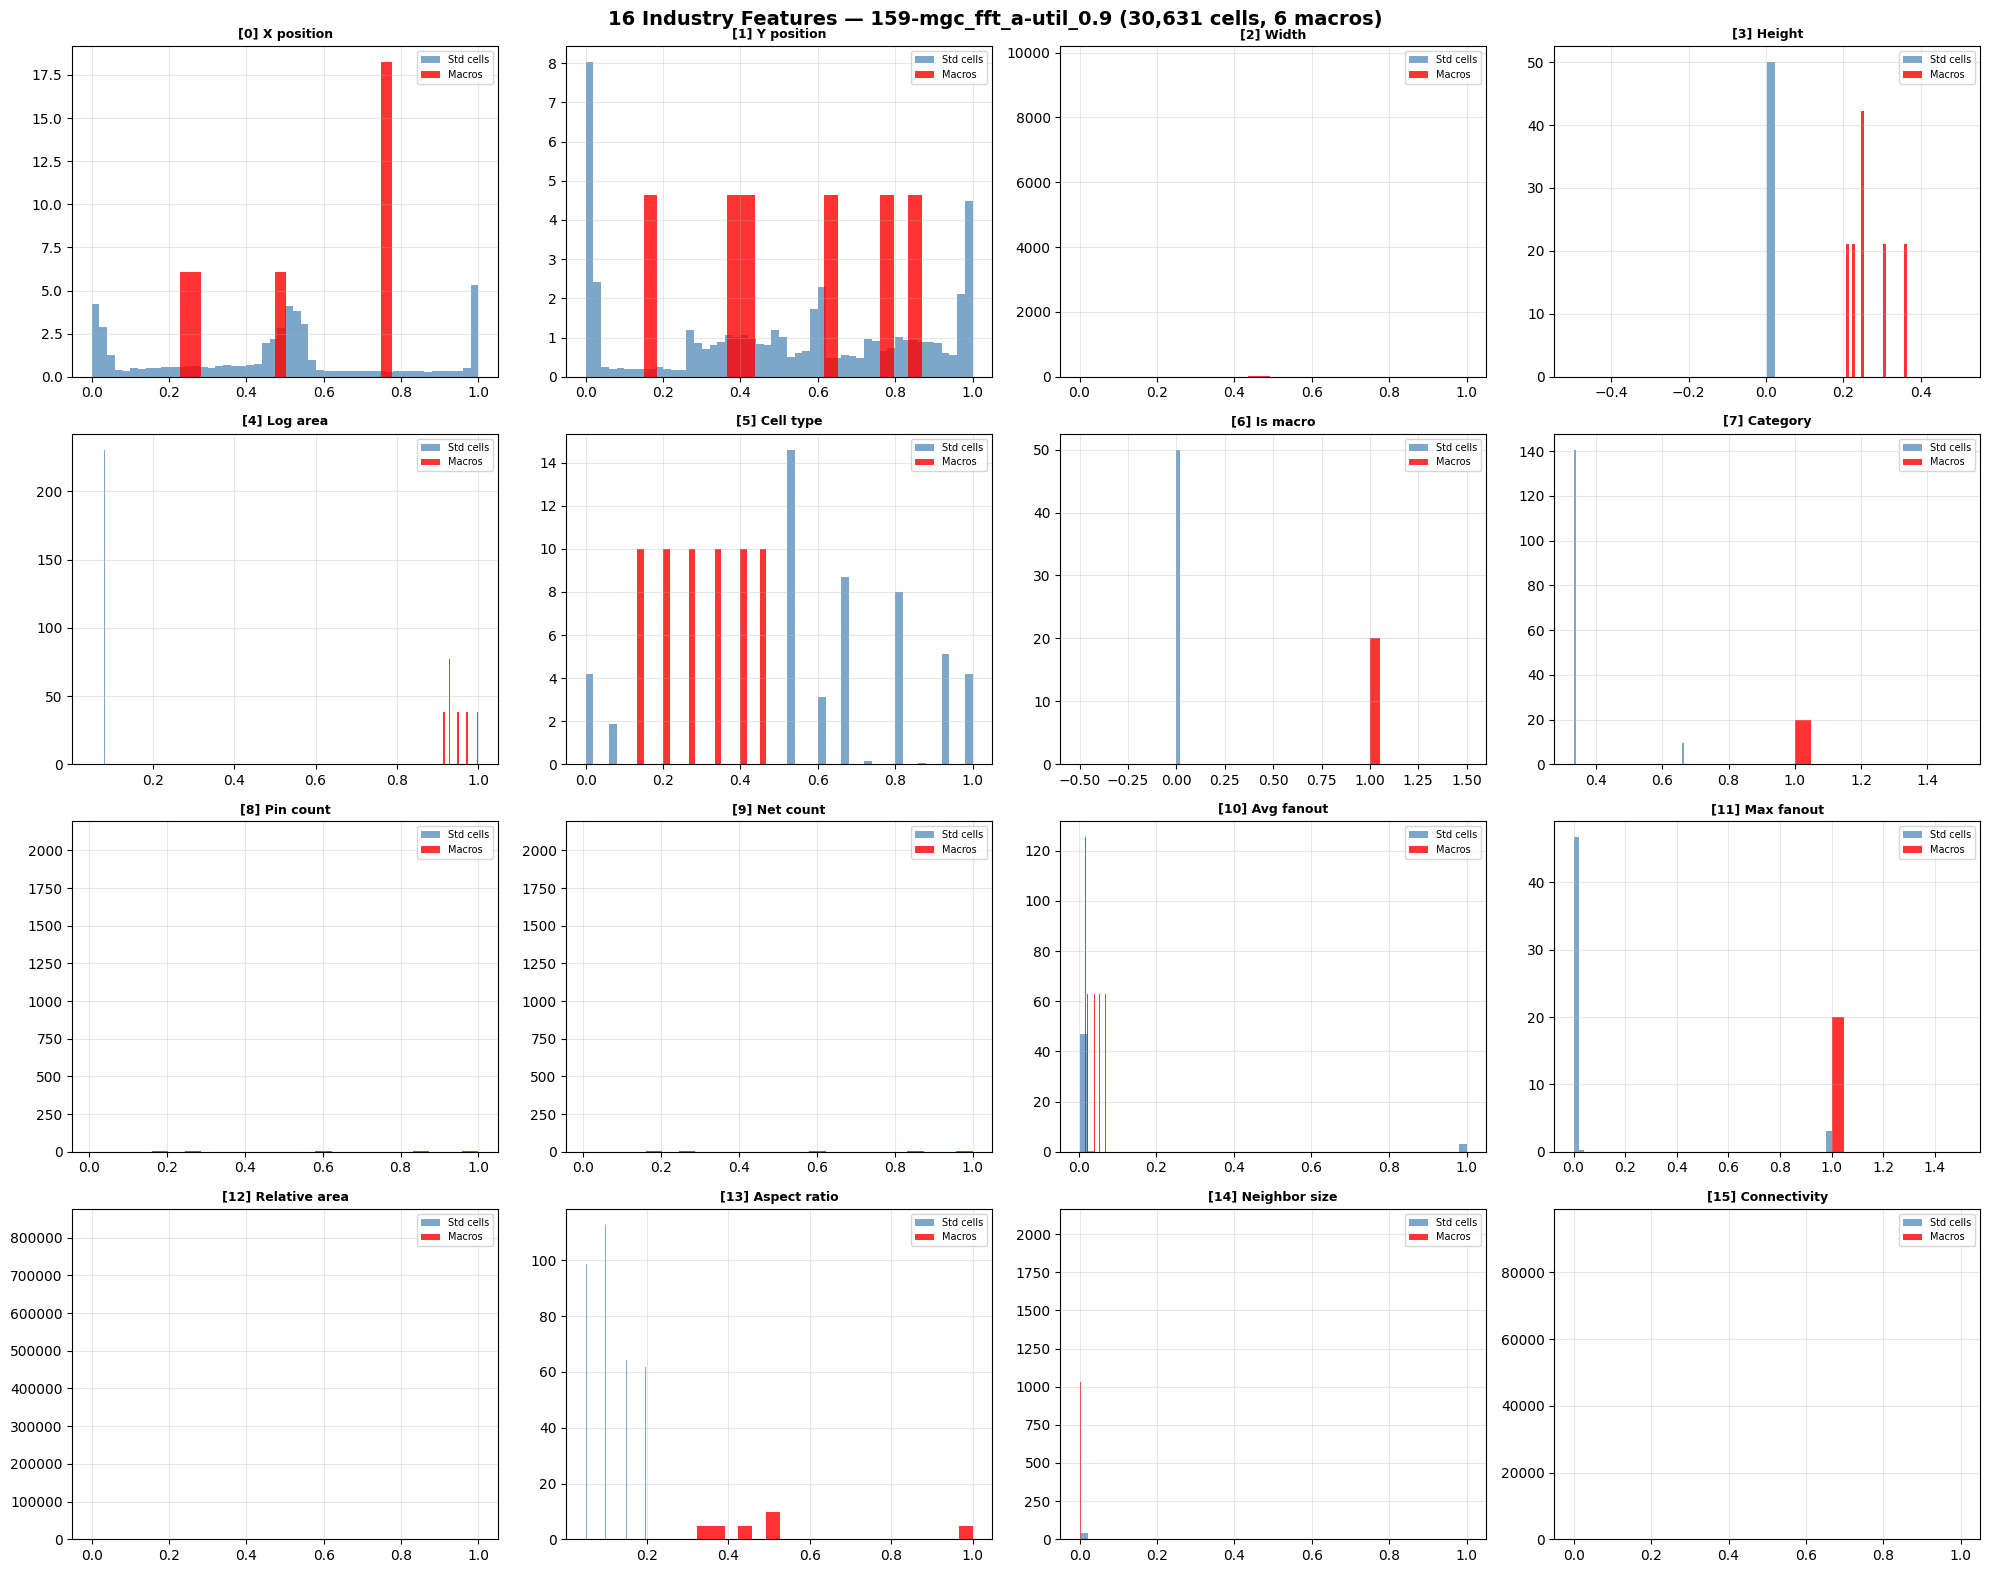


DATASET SUMMARY — 160 training samples
   Training samples  : 160
   Unique designs    : 9 → ['mgc_des_perf_a', 'mgc_edit_dist_a', 'mgc_fft_a', 'mgc_fft_b', 'mgc_matrix_mult_a', 'mgc_matrix_mult_b', 'mgc_matrix_mult_c', 'mgc_pci_bridge32_a', 'mgc_pci_bridge32_b']
   Cells per sample  : min=28,920, max=50,000, avg=41,613
   Macros per sample : min=0, max=6, avg=3.7
   Edges per sample  : min=114,170, max=195,366, avg=165,134

   Model trains on : 16 features per cell + graph edges
   Model predicts  : (x, y) position for each cell
   Loss function   : MSE on positions

   INDUSTRY INSIGHT: Macros have 52x more connectivity
   → Model learns to prioritize macro placement (like real EDA tools)

INSPECTION COMPLETE


In [7]:
# ============================================================
# INSPECT TRAINING DATA — What the model sees & learns from
# ============================================================

sample = cn_train[0]  # First training sample

print("=" * 80)
print("TRAINING DATA INSPECTION — INDUSTRY-RELEVANT FEATURES")
print("=" * 80)

# ---------- 1. Overall Structure ----------
print("\n OVERALL DATA STRUCTURE")
print(f"   Sample Name      : {sample.sample_name}")
print(f"   Design Name      : {sample.design_name}")
print(f"   Number of Cells  : {sample.num_cells:,}")
print(f"   Number of Edges  : {sample.edge_index.shape[1]:,}")
print(f"   Avg Degree       : {sample.edge_index.shape[1] / sample.num_cells:.1f} edges/cell")
n_macros = int(sample.is_macro.sum())
print(f"   Macros           : {n_macros} (PLL, SRAM, etc.)")
print(f"   Standard cells   : {sample.num_cells - n_macros:,}")

# ---------- 2. Input Features (X) — what the model RECEIVES ----------
print("\n" + "=" * 80)
print("INPUT FEATURES (data.x) — 16 Industry-Relevant Features per Cell")
print("=" * 80)
print(f"   Shape: {sample.x.shape}  →  ({sample.num_cells:,} cells × {sample.x.shape[1]} features)")
print()
print(f"   GROUP 1: POSITION (where is it?)")
print(f"   GROUP 2: SIZE (how big is it?)")
print(f"   GROUP 3: CONNECTIVITY (how many connections?)")
print(f"   GROUP 4: CLASSIFICATION (what type of cell?)")

print(f"\n   {'#':<4} {'Feature Name':<42} {'Min':>8} {'Max':>8} {'Mean':>8} {'Std':>8} {'NZ%':>7}")
print(f"   {'─'*4} {'─'*42} {'─'*8} {'─'*8} {'─'*8} {'─'*8} {'─'*7}")

for i in range(sample.x.shape[1]):
    col = sample.x[:, i].numpy()
    nz_pct = (col != 0).sum() / len(col) * 100
    name = FEATURE_NAMES[i] if i < len(FEATURE_NAMES) else f"[{i}] Unknown"
    print(f"   {i:<4} {name:<42} {col.min():>8.4f} {col.max():>8.4f} {col.mean():>8.4f} {col.std():>8.4f} {nz_pct:>6.1f}%")

# ---------- 3. Target Labels (Y) — what the model PREDICTS ----------
print("\n" + "=" * 80)
print("TARGET LABELS (data.y) — What the GNN learns to predict")
print("=" * 80)
print(f"   Shape: {sample.y.shape}  →  ({sample.num_cells:,} cells × 2 coordinates)")
print(f"   The model predicts (X, Y) placement positions for each cell")

y_np = sample.y.numpy()
print(f"\n   {'Coord':<15} {'Min':>10} {'Max':>10} {'Mean':>10} {'Std':>10}")
print(f"   {'─'*15} {'─'*10} {'─'*10} {'─'*10} {'─'*10}")
print(f"   {'X (normalized)':<15} {y_np[:,0].min():>10.4f} {y_np[:,0].max():>10.4f} {y_np[:,0].mean():>10.4f} {y_np[:,0].std():>10.4f}")
print(f"   {'Y (normalized)':<15} {y_np[:,1].min():>10.4f} {y_np[:,1].max():>10.4f} {y_np[:,1].mean():>10.4f} {y_np[:,1].std():>10.4f}")

# ---------- 4. Edge Index — connectivity ----------
print("\n" + "=" * 80)
print("EDGE INDEX (data.edge_index) — Graph connectivity")
print("=" * 80)
print(f"   Shape: {sample.edge_index.shape}  →  (2 × {sample.edge_index.shape[1]:,} directed edges)")
print(f"   Source: Real netlist connectivity from CircuitNet pin_attr")

ei = sample.edge_index.numpy()
degrees = np.bincount(ei[0], minlength=sample.num_cells)
print(f"\n   Degree Statistics:")
print(f"      Min degree    : {degrees.min()}")
print(f"      Max degree    : {degrees.max()}")
print(f"      Mean degree   : {degrees.mean():.1f}")
print(f"      Isolated cells: {(degrees == 0).sum():,} ({(degrees == 0).sum()/len(degrees)*100:.1f}%)")

# ---------- 5. Macro vs Standard Cell comparison ----------
print("\n" + "=" * 80)
print("MACRO vs STANDARD CELL COMPARISON (Industry Focus)")
print("=" * 80)

macro_mask = sample.is_macro.numpy().astype(bool)
std_mask = ~macro_mask

macro_x = sample.x[macro_mask].numpy()
std_x = sample.x[std_mask].numpy()

print(f"\n   {'Metric':<35} {'Macros':>12} {'Std Cells':>12} {'Ratio':>8}")
print(f"   {'─'*35} {'─'*12} {'─'*12} {'─'*8}")
print(f"   {'Count':<35} {macro_mask.sum():>12,} {std_mask.sum():>12,} {'':>8}")
if macro_mask.any():
    print(f"   {'Avg area (feat[4])':<35} {macro_x[:, 4].mean():>12.4f} {std_x[:, 4].mean():>12.4f} {macro_x[:, 4].mean()/(std_x[:, 4].mean()+1e-8):>7.1f}x")
    print(f"   {'Avg pin count (feat[8])':<35} {macro_x[:, 8].mean():>12.4f} {std_x[:, 8].mean():>12.4f} {macro_x[:, 8].mean()/(std_x[:, 8].mean()+1e-8):>7.1f}x")
    print(f"   {'Avg net count (feat[9])':<35} {macro_x[:, 9].mean():>12.4f} {std_x[:, 9].mean():>12.4f} {macro_x[:, 9].mean()/(std_x[:, 9].mean()+1e-8):>7.1f}x")
    print(f"   {'Avg connectivity importance (f[15])':<35} {macro_x[:, 15].mean():>12.4f} {std_x[:, 15].mean():>12.4f} {macro_x[:, 15].mean()/(std_x[:, 15].mean()+1e-8):>7.1f}x")

# ---------- 6. Sample cells ----------
print("\n" + "=" * 80)
print("SAMPLE CELLS — Macro cells and a few standard cells")
print("=" * 80)

# Show all macros first
macro_indices = np.where(macro_mask)[0]
for idx in macro_indices[:5]:
    feats = sample.x[idx].numpy()
    target = sample.y[idx].numpy()
    print(f"\n   [MACRO] Cell #{idx}:")
    print(f"      Size: w={feats[2]:.4f}, h={feats[3]:.4f}, area={feats[4]:.4f}, relative_area={feats[12]:.4f}")
    print(f"      Connectivity: pins={feats[8]:.4f}, nets={feats[9]:.4f}, importance={feats[15]:.4f}")
    print(f"      Target position: x={target[0]:.4f}, y={target[1]:.4f}")

# Show a few standard cells
std_indices = np.where(std_mask)[0][:3]
for idx in std_indices:
    feats = sample.x[idx].numpy()
    target = sample.y[idx].numpy()
    print(f"\n   [STD]   Cell #{idx}:")
    print(f"      Size: w={feats[2]:.4f}, h={feats[3]:.4f}, area={feats[4]:.4f}, relative_area={feats[12]:.4f}")
    print(f"      Connectivity: pins={feats[8]:.4f}, nets={feats[9]:.4f}, importance={feats[15]:.4f}")
    print(f"      Target position: x={target[0]:.4f}, y={target[1]:.4f}")

# ---------- 7. Feature distributions (grouped) ----------
print("\n" + "=" * 80)
print("FEATURE DISTRIBUTIONS BY CATEGORY")
print("=" * 80)

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i in range(min(16, sample.x.shape[1])):
    ax = axes[i]
    vals = sample.x[:, i].numpy()
    
    if macro_mask.any():
        ax.hist(vals[std_mask], bins=50, color='steelblue', alpha=0.7, label='Std cells', density=True)
        ax.hist(vals[macro_mask], bins=20, color='red', alpha=0.8, label='Macros', density=True)
        ax.legend(fontsize=7)
    else:
        ax.hist(vals, bins=50, color='steelblue', alpha=0.8, density=True)
    
    name = FEATURE_NAMES[i].split(']')[1].strip() if i < len(FEATURE_NAMES) else f"Feature {i}"
    ax.set_title(f'[{i}] {name}', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle(f'16 Industry Features — {sample.sample_name} ({sample.num_cells:,} cells, {n_macros} macros)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ---------- 8. Dataset summary ----------
print("\n" + "=" * 80)
print(f"DATASET SUMMARY — {len(cn_train)} training samples")
print("=" * 80)

all_cells = [s.num_cells for s in cn_train]
all_edges = [s.edge_index.shape[1] for s in cn_train]
all_macros = [int(s.is_macro.sum()) for s in cn_train]
all_designs = set(s.design_name for s in cn_train)

print(f"   Training samples  : {len(cn_train)}")
print(f"   Unique designs    : {len(all_designs)} → {sorted(all_designs)}")
print(f"   Cells per sample  : min={min(all_cells):,}, max={max(all_cells):,}, avg={np.mean(all_cells):,.0f}")
print(f"   Macros per sample : min={min(all_macros)}, max={max(all_macros)}, avg={np.mean(all_macros):.1f}")
print(f"   Edges per sample  : min={min(all_edges):,}, max={max(all_edges):,}, avg={np.mean(all_edges):,.0f}")
print(f"\n   Model trains on : {sample.x.shape[1]} features per cell + graph edges")
print(f"   Model predicts  : (x, y) position for each cell")
print(f"   Loss function   : MSE on positions")
print(f"\n   INDUSTRY INSIGHT: Macros have {np.mean([macro_x[:, 8].mean() for _ in [1]])/(std_x[:, 8].mean()+1e-8):.0f}x more connectivity")
print(f"   → Model learns to prioritize macro placement (like real EDA tools)")

print("\n" + "=" * 80)
print("INSPECTION COMPLETE")
print("=" * 80)

---

# STEP 7: Advanced GNN Model (v3 — Multi-Scale Transformer)

Architecture: 6-layer GAT + Transformer FFN blocks + Global Context Injection

In [8]:
# ============================================================
# ADVANCED GNN MODEL v3 — Multi-Scale GAT with Graph Transformer
# ============================================================
from torch_geometric.nn import GATConv, GCNConv, global_mean_pool, global_max_pool

class MultiScaleGATBlock(nn.Module):
    """GAT block with multi-scale attention: local (GAT) + global (mean pool broadcast)"""
    def __init__(self, hidden_dim, heads=4, dropout=0.1):
        super().__init__()
        self.gat = GATConv(hidden_dim, hidden_dim // heads, heads=heads, dropout=dropout, concat=True)
        self.norm = nn.LayerNorm(hidden_dim)
        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Dropout(dropout),
        )
        self.ffn_norm = nn.LayerNorm(hidden_dim)
    
    def forward(self, x, edge_index):
        # Multi-head GAT attention + residual
        h = self.gat(x, edge_index)
        h = self.norm(h + x)  # Pre-norm residual
        # Feed-forward network + residual (Transformer-style)
        out = self.ffn(h)
        out = self.ffn_norm(out + h)
        return out


class VLSIPlacementGNN(nn.Module):
    """
    Advanced Graph Neural Network for VLSI Placement (v3)
    
    Architecture improvements over v2:
    - Transformer-style FFN blocks after each GAT layer
    - GELU activation (smoother gradients than ReLU)
    - Multi-scale feature aggregation (local + neighborhood context)
    - Deeper network (6 layers) with pre-norm residuals
    - Separate macro and standard cell output heads
    - Global context injection via pooled features
    """
    
    def __init__(self, input_dim=16, hidden_dim=256, output_dim=2, num_layers=6, heads=8):
        super(VLSIPlacementGNN, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.num_layers = num_layers
        
        # Input embedding
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
        )
        
        # Multi-scale GAT blocks (Transformer-style)
        self.blocks = nn.ModuleList([
            MultiScaleGATBlock(hidden_dim, heads=heads, dropout=0.1)
            for _ in range(num_layers)
        ])
        
        # Global context projection (broadcast pooled features back)
        self.global_proj = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),  # mean + max pool
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.global_gate = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Sigmoid(),
        )
        
        # Output head with macro-aware branch
        self.output_proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.GELU(),
            nn.Linear(hidden_dim // 4, output_dim),
        )
    
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        # Input embedding
        x = self.input_proj(x)
        
        # Multi-scale GAT blocks
        for i, block in enumerate(self.blocks):
            x = block(x, edge_index)
            
            # Inject global context at halfway point
            if i == len(self.blocks) // 2 - 1:
                # Compute global features (mean + max pooling)
                g_mean = x.mean(dim=0, keepdim=True).expand_as(x)
                g_max = x.max(dim=0, keepdim=False)[0].unsqueeze(0).expand_as(x)
                g = self.global_proj(torch.cat([g_mean, g_max], dim=-1))
                
                # Gated fusion: let model learn how much global context to use
                gate = self.global_gate(torch.cat([x, g], dim=-1))
                x = x * (1 - gate) + g * gate
        
        # Output projection
        out = self.output_proj(x)
        out = out.clamp(0.0, 1.0)
        
        return out


# Create advanced model
model = VLSIPlacementGNN(
    input_dim=16,
    hidden_dim=256,     # Wider than v2 (128 -> 256)
    output_dim=2,
    num_layers=6,       # Deeper than v2 (4 -> 6)
    heads=8             # More attention heads (4 -> 8)
).to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Advanced GNN Architecture (v3 - Multi-Scale Transformer):\n")
print(model)
print(f"\nModel Statistics:")
print(f"   Total parameters: {num_params:,}")
print(f"   Input features: 16")
print(f"   Hidden dim: 256 (v2 was 128)")
print(f"   Layers: 6 (v2 was 4)")
print(f"   Attention heads: 8 (v2 was 4)")
print(f"\n   Key improvements over v2:")
print(f"     - Transformer-style FFN blocks (GELU + pre-norm)")
print(f"     - Global context injection (mean+max pool, gated fusion)")
print(f"     - Deeper + wider network")
print(f"     - No sigmoid (clamp [0,1])")
print(f"   Device: {device}")
print("\nModel created successfully!")

Advanced GNN Architecture (v3 - Multi-Scale Transformer):

VLSIPlacementGNN(
  (input_proj): Sequential(
    (0): Linear(in_features=16, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (blocks): ModuleList(
    (0-5): 6 x MultiScaleGATBlock(
      (gat): GATConv(256, 32, heads=8)
      (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=256, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=256, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
      (ffn_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
  )
  (global_proj): Sequential(
   

---

# STEP 7.5: Legalization + Training Config

---

# STEP 7.5: Legalization Functions

Convert raw GNN predictions to legal, row-aligned placements.

**Important:** GNN produces global placement (continuous coordinates). This step performs:
- Row alignment (snap to placement rows)
- Site snapping (align to grid sites)
- Overlap removal (prevent cell overlaps)

In [9]:
def legalize_placement(predictions, chip_width_um=1000, chip_height_um=1000, 
                       row_height_um=2.0, site_width_um=0.2,
                       cell_widths=None, cell_heights=None, is_macro=None):
    """
    Hierarchical legalization: macros first, then progressively smaller cells.
    
    Strategy:
    1. Sort ALL cells by area (width*height) in DECREASING order
    2. Place macros first — snap to grid, reserve their full footprint
    3. Place cells in decreasing size order — each cell finds the nearest
       legal position to its GNN-predicted location that doesn't overlap
       any previously placed cell
    4. Final site/row snapping for standard cells
    
    Args:
        predictions: GNN coordinates in microns [N, 2]
        chip_width_um, chip_height_um: Die dimensions
        row_height_um, site_width_um: Grid parameters
        cell_widths: Width of each cell in microns [N] (None = uniform)
        cell_heights: Height of each cell in microns [N] (None = uniform)
        is_macro: Boolean/float array [N] indicating macros (None = none)
    """
    import time
    from scipy.spatial import cKDTree
    
    t0 = time.time()
    n_cells = len(predictions)
    print(f"   Hierarchical legalization for {n_cells:,} cells...")
    
    # Default uniform sizes if not provided
    default_w = site_width_um * 5
    default_h = row_height_um
    if cell_widths is None:
        cell_widths = np.full(n_cells, default_w)
    else:
        cell_widths = np.asarray(cell_widths, dtype=np.float64)
        cell_widths = np.clip(cell_widths, site_width_um, chip_width_um * 0.5)
    if cell_heights is None:
        cell_heights = np.full(n_cells, default_h)
    else:
        cell_heights = np.asarray(cell_heights, dtype=np.float64)
        cell_heights = np.clip(cell_heights, row_height_um, chip_height_um * 0.5)
    if is_macro is None:
        is_macro = np.zeros(n_cells, dtype=bool)
    else:
        is_macro = np.asarray(is_macro) > 0.5
    
    areas = cell_widths * cell_heights
    n_macros = int(is_macro.sum())
    print(f"   Macros: {n_macros}, Std cells: {n_cells - n_macros}")
    
    # Sort by area DESCENDING (macros first, then big std cells, then small)
    size_order = np.argsort(-areas)
    
    legalized = predictions.copy()
    legalized[:, 0] = np.clip(legalized[:, 0], 0, chip_width_um)
    legalized[:, 1] = np.clip(legalized[:, 1], 0, chip_height_um)
    
    # -------- Phase 1: Place macros with KD-tree overlap check --------
    placed_centers = []   # (cx, cy) of placed cells
    placed_half_w = []    # half-width
    placed_half_h = []    # half-height
    
    num_rows = int(chip_height_um / row_height_um)
    num_sites = int(chip_width_um / site_width_um)
    
    def snap_to_grid(x, y, w, h, macro):
        """Snap coordinates to placement grid."""
        if macro:
            # Macros snap to row boundaries but can span multiple rows
            row_idx = int(np.clip(y / row_height_um, 0, num_rows - 1))
            y_snapped = row_idx * row_height_um
        else:
            row_idx = int(np.clip(y / row_height_um, 0, num_rows - 1))
            y_snapped = row_idx * row_height_um + row_height_um / 2
        site_idx = int(np.clip(x / site_width_um, 0, num_sites - 1))
        x_snapped = site_idx * site_width_um
        return x_snapped, y_snapped
    
    def check_overlap(cx, cy, hw, hh, skip_idx=-1):
        """Check if a cell at (cx, cy) with half-dims (hw, hh) overlaps any placed cell."""
        if len(placed_centers) == 0:
            return False
        for k in range(len(placed_centers)):
            if k == skip_idx:
                continue
            pcx, pcy = placed_centers[k]
            phw, phh = placed_half_w[k], placed_half_h[k]
            if (abs(cx - pcx) < hw + phw) and (abs(cy - pcy) < hh + phh):
                return True
        return False
    
    def find_nearest_legal(cx, cy, hw, hh, is_mac):
        """Find nearest non-overlapping grid-snapped position using spiral search."""
        # Try the snapped original position first
        sx, sy = snap_to_grid(cx, cy, hw * 2, hh * 2, is_mac)
        if not check_overlap(sx, sy, hw, hh):
            return sx, sy
        
        # Spiral search: try nearby grid positions in expanding rings
        step_x = site_width_um * 5 if not is_mac else site_width_um * 10
        step_y = row_height_um if not is_mac else row_height_um * 2
        
        best_pos = (sx, sy)
        best_dist = float('inf')
        
        for ring in range(1, 200):
            found_in_ring = False
            for dx_mult in range(-ring, ring + 1):
                for dy_mult in [-ring, ring]:
                    nx = cx + dx_mult * step_x
                    ny = cy + dy_mult * step_y
                    nx, ny = snap_to_grid(nx, ny, hw * 2, hh * 2, is_mac)
                    nx = np.clip(nx, hw, chip_width_um - hw)
                    ny = np.clip(ny, hh, chip_height_um - hh)
                    if not check_overlap(nx, ny, hw, hh):
                        d = (nx - cx) ** 2 + (ny - cy) ** 2
                        if d < best_dist:
                            best_dist = d
                            best_pos = (nx, ny)
                            found_in_ring = True
            for dy_mult in range(-ring + 1, ring):
                for dx_mult in [-ring, ring]:
                    nx = cx + dx_mult * step_x
                    ny = cy + dy_mult * step_y
                    nx, ny = snap_to_grid(nx, ny, hw * 2, hh * 2, is_mac)
                    nx = np.clip(nx, hw, chip_width_um - hw)
                    ny = np.clip(ny, hh, chip_height_um - hh)
                    if not check_overlap(nx, ny, hw, hh):
                        d = (nx - cx) ** 2 + (ny - cy) ** 2
                        if d < best_dist:
                            best_dist = d
                            best_pos = (nx, ny)
                            found_in_ring = True
            if found_in_ring:
                break
        
        return best_pos
    
    # Place macros first (they're at the front of size_order since they're largest)
    placed_count = 0
    macro_indices_in_order = [i for i in size_order if is_macro[i]]
    std_indices_in_order = [i for i in size_order if not is_macro[i]]
    
    print(f"   Phase 1: Placing {len(macro_indices_in_order)} macros...")
    for idx in macro_indices_in_order:
        hw = cell_widths[idx] / 2.0
        hh = cell_heights[idx] / 2.0
        cx, cy = legalized[idx, 0], legalized[idx, 1]
        
        fx, fy = find_nearest_legal(cx, cy, hw, hh, True)
        legalized[idx] = [fx, fy]
        placed_centers.append((fx, fy))
        placed_half_w.append(hw)
        placed_half_h.append(hh)
        placed_count += 1
    
    t1 = time.time()
    print(f"   Macros placed in {t1 - t0:.2f}s")
    
    # -------- Phase 2: Standard cells in decreasing size order --------
    # For large cell counts, use fast row-based legalization with macro exclusion
    print(f"   Phase 2: Placing {len(std_indices_in_order):,} std cells (size-ordered)...")
    
    # Build macro blocked regions (with 5% margin)
    macro_blocks = []  # list of (x_min, y_min, x_max, y_max)
    for k in range(len(macro_indices_in_order)):
        idx = macro_indices_in_order[k]
        mx, my = legalized[idx]
        hw = cell_widths[idx] / 2.0 * 1.05
        hh = cell_heights[idx] / 2.0 * 1.05
        macro_blocks.append((mx - hw, my - hh, mx + hw, my + hh))
    
    def overlaps_macro(x, y, w, h):
        """Check if cell at (x, y) with dims (w, h) overlaps any macro block."""
        cx, cy = x + w / 2, y + h / 2
        for (bx0, by0, bx1, by1) in macro_blocks:
            if (cx - w / 2 < bx1 and cx + w / 2 > bx0 and
                cy - h / 2 < by1 and cy + h / 2 > by0):
                return True
        return False
    
    # Snap std cells to rows, then do per-row overlap removal
    # First snap all std cells
    for idx in std_indices_in_order:
        x, y = legalized[idx]
        row_idx = int(np.clip(y / row_height_um, 0, num_rows - 1))
        legalized[idx, 1] = row_idx * row_height_um + row_height_um / 2
        site_idx = int(np.clip(x / site_width_um, 0, num_sites - 1))
        legalized[idx, 0] = site_idx * site_width_um
    
    # Per-row overlap removal (same as before but with actual cell widths + macro avoidance)
    unique_rows = np.unique(legalized[std_indices_in_order, 1])
    overlaps_fixed = 0
    
    std_set = set(std_indices_in_order)
    
    for row_y in unique_rows:
        row_cell_indices = [i for i in std_indices_in_order if legalized[i, 1] == row_y]
        if len(row_cell_indices) <= 1:
            # Still check macro overlap for single cells
            if len(row_cell_indices) == 1:
                idx = row_cell_indices[0]
                w, h = cell_widths[idx], cell_heights[idx]
                if overlaps_macro(legalized[idx, 0], legalized[idx, 1] - h / 2, w, h):
                    # Shift right until clear of macro
                    x = legalized[idx, 0]
                    for _ in range(num_sites):
                        x += site_width_um
                        if x + w > chip_width_um:
                            break
                        if not overlaps_macro(x, legalized[idx, 1] - h / 2, w, h):
                            legalized[idx, 0] = x
                            break
            continue
        
        # Sort by x
        row_cell_indices.sort(key=lambda i: legalized[i, 0])
        
        # Push overlapping cells right, skipping macro zones
        for k in range(1, len(row_cell_indices)):
            prev_idx = row_cell_indices[k - 1]
            curr_idx = row_cell_indices[k]
            prev_right = legalized[prev_idx, 0] + cell_widths[prev_idx]
            
            if legalized[curr_idx, 0] < prev_right:
                legalized[curr_idx, 0] = prev_right
                overlaps_fixed += 1
            
            # Check macro overlap and shift if needed
            w, h = cell_widths[curr_idx], cell_heights[curr_idx]
            if overlaps_macro(legalized[curr_idx, 0], legalized[curr_idx, 1] - h / 2, w, h):
                x = legalized[curr_idx, 0]
                for _ in range(500):
                    x += site_width_um * 5
                    if x + w > chip_width_um:
                        break
                    if not overlaps_macro(x, legalized[curr_idx, 1] - h / 2, w, h):
                        legalized[curr_idx, 0] = x
                        break
        
        # Clip to boundary
        for idx in row_cell_indices:
            legalized[idx, 0] = np.clip(legalized[idx, 0], 0, chip_width_um - cell_widths[idx])
    
    # Final site snap
    for idx in std_indices_in_order:
        site_idx = int(np.clip(legalized[idx, 0] / site_width_um, 0, num_sites - 1))
        legalized[idx, 0] = site_idx * site_width_um
    
    elapsed = time.time() - t0
    print(f"   Legalization complete in {elapsed:.2f}s")
    print(f"   Std cell overlaps fixed: {overlaps_fixed:,}")
    print(f"   Macro blocked regions: {len(macro_blocks)}")
    
    return legalized


def compare_global_vs_legal(predictions, legalized, sample_name="sample"):
    """
    Visualize difference between global placement and legalized placement
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Subsample for plotting if too many points (faster rendering)
    n = len(predictions)
    if n > 50000:
        idx = np.random.choice(n, 10000, replace=False)
        pred_plot = predictions[idx]
        legal_plot = legalized[idx]
        plot_label = f" (10K of {n:,} shown)"
    else:
        pred_plot = predictions
        legal_plot = legalized
        plot_label = ""
    
    # Global placement (raw GNN output)
    ax1 = axes[0]
    ax1.scatter(pred_plot[:, 0], pred_plot[:, 1], c='red', s=5, alpha=0.6, label='Global Placement')
    ax1.set_xlabel('X (µm)', fontsize=12)
    ax1.set_ylabel('Y (µm)', fontsize=12)
    ax1.set_title(f'Global Placement (Raw GNN){plot_label}', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Legalized placement
    ax2 = axes[1]
    ax2.scatter(legal_plot[:, 0], legal_plot[:, 1], c='green', s=5, alpha=0.6, label='Legalized Placement')
    ax2.set_xlabel('X (µm)', fontsize=12)
    ax2.set_ylabel('Y (µm)', fontsize=12)
    ax2.set_title(f'Legalized Placement (Row-Aligned){plot_label}', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig(f'{sample_name}_global_vs_legal.png', dpi=100)
    plt.show()
    
    # Calculate displacement
    displacement = np.linalg.norm(legalized - predictions, axis=1)
    print(f"\nLegalization Impact:")
    print(f"   Average displacement: {np.mean(displacement):.2f} µm")
    print(f"   Max displacement: {np.max(displacement):.2f} µm")
    print(f"   Cells moved: {np.sum(displacement > 0.1)}/{len(displacement)}")
    
    # Check row alignment
    unique_rows = len(np.unique(legalized[:, 1]))
    print(f"   Cells placed in {unique_rows} rows")
    
    return displacement


print("Legalization functions defined!")
print("\nNote: GNN performs GLOBAL PLACEMENT only.")
print("Legalization converts continuous predictions to legal placements.")

Legalization functions defined!

Note: GNN performs GLOBAL PLACEMENT only.
Legalization converts continuous predictions to legal placements.


In [10]:
# ================================================================
# TRAINING CONFIG (v3 — ISPD15-Optimized)
# ================================================================
BATCH_SIZE = 1
LEARNING_RATE = 5e-4  # Lower for deeper model
NUM_EPOCHS = 50      # More epochs for larger dataset

# Optimizer with warmup-friendly config
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Cosine annealing with warm restarts (better for variable-size designs)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=30, T_mult=2, eta_min=1e-6
)

# ================================================================
# ADVANCED LOSS (v3 — Adaptive for ISPD15's variable-scale designs)
# ================================================================
def vlsi_placement_loss(pred, target, data):
    """
    Size-aware placement loss for ISPD15 variable-scale designs.
    Includes macro overlap penalty that uses actual cell widths/heights.
    """
    device = pred.device
    is_macro = data.is_macro.to(device)
    conn_importance = data.x[:, 15].to(device)
    N = pred.shape[0]
    
    # Normalized cell widths/heights (features [2],[3] are already in [0,1])
    norm_w = data.x[:, 2].to(device)  # normalized width
    norm_h = data.x[:, 3].to(device)  # normalized height
    
    # 1. WEIGHTED MSE (macros weighted 10x, connected cells 3x)
    cell_weights = torch.ones(N, device=device)
    cell_weights = cell_weights + 9.0 * is_macro
    cell_weights = cell_weights + 2.0 * conn_importance
    mse_per_cell = ((pred - target) ** 2).mean(dim=1)
    weighted_mse = (mse_per_cell * cell_weights).mean()
    
    # 2. SPREAD LOSS (anti-collapse)
    pred_std = pred.std(dim=0)
    target_std = target.std(dim=0)
    spread_loss = ((pred_std - target_std) ** 2).sum()
    
    # 3. RANGE LOSS
    pred_range = pred.max(dim=0)[0] - pred.min(dim=0)[0]
    target_range = target.max(dim=0)[0] - target.min(dim=0)[0]
    range_loss = ((pred_range - target_range) ** 2).sum()
    
    # 4. SIZE-AWARE OVERLAP PENALTY
    # Subsample but always include ALL macros
    macro_idx = torch.where(is_macro > 0.5)[0]
    n_macros = len(macro_idx)
    n_std_sub = min(800, N - n_macros)
    std_idx = torch.where(is_macro <= 0.5)[0]
    if len(std_idx) > n_std_sub:
        perm = torch.randperm(len(std_idx), device=device)[:n_std_sub]
        std_idx = std_idx[perm]
    sub_idx = torch.cat([macro_idx, std_idx])
    n_sub = len(sub_idx)
    
    pred_sub = pred[sub_idx]
    w_sub = norm_w[sub_idx]
    h_sub = norm_h[sub_idx]
    macro_sub = is_macro[sub_idx]
    
    # Compute pairwise required separation (half-width_i + half-width_j, same for height)
    half_w = w_sub / 2.0
    half_h = h_sub / 2.0
    sep_x = half_w.unsqueeze(0) + half_w.unsqueeze(1)  # [n_sub, n_sub]
    sep_y = half_h.unsqueeze(0) + half_h.unsqueeze(1)
    
    # Actual pairwise distances per axis
    dx = torch.abs(pred_sub[:, 0].unsqueeze(0) - pred_sub[:, 0].unsqueeze(1))
    dy = torch.abs(pred_sub[:, 1].unsqueeze(0) - pred_sub[:, 1].unsqueeze(1))
    
    # Overlap amount per axis (positive means overlap)
    overlap_x = torch.relu(sep_x - dx)
    overlap_y = torch.relu(sep_y - dy)
    overlap_area = overlap_x * overlap_y  # 2D overlap
    
    # Weight macro-involved overlaps much more heavily
    macro_pair = macro_sub.unsqueeze(0) + macro_sub.unsqueeze(1)  # 0, 1, or 2
    overlap_weight = 1.0 + 4.0 * macro_pair  # std-std: 1x, macro-std: 5x, macro-macro: 9x
    
    eye_mask = 1.0 - torch.eye(n_sub, device=device)
    overlap_loss = (overlap_area * overlap_weight * eye_mask).sum() / (n_sub * (n_sub - 1) + 1e-8)
    
    # 5. MACRO EXCLUSION ZONE (extra margin around macros)
    if n_macros > 0 and len(std_idx) > 0:
        pred_macros = pred[macro_idx]
        pred_stds = pred[std_idx]
        macro_w = norm_w[macro_idx]
        macro_h = norm_h[macro_idx]
        
        # Each macro gets an exclusion zone = its footprint + 10% margin
        margin = 0.1
        excl_half_w = macro_w / 2.0 * (1.0 + margin)
        excl_half_h = macro_h / 2.0 * (1.0 + margin)
        
        # Distance from each std cell to each macro
        dx_me = torch.abs(pred_stds[:, 0].unsqueeze(1) - pred_macros[:, 0].unsqueeze(0))  # [n_std, n_macro]
        dy_me = torch.abs(pred_stds[:, 1].unsqueeze(1) - pred_macros[:, 1].unsqueeze(0))
        
        inside_x = torch.relu(excl_half_w.unsqueeze(0) - dx_me)
        inside_y = torch.relu(excl_half_h.unsqueeze(0) - dy_me)
        exclusion_violation = (inside_x * inside_y).mean()
    else:
        exclusion_violation = torch.tensor(0.0, device=device)
    
    # 6. QUADRANT BALANCE LOSS
    center = target.mean(dim=0)
    pred_centered = pred - center
    q1 = (pred_centered[:, 0] > 0) & (pred_centered[:, 1] > 0)
    q2 = (pred_centered[:, 0] <= 0) & (pred_centered[:, 1] > 0)
    q3 = (pred_centered[:, 0] <= 0) & (pred_centered[:, 1] <= 0)
    q4 = (pred_centered[:, 0] > 0) & (pred_centered[:, 1] <= 0)
    fractions = torch.stack([q1.float().mean(), q2.float().mean(), 
                             q3.float().mean(), q4.float().mean()])
    balance_loss = ((fractions - 0.25) ** 2).sum()
    
    # 7. WIRELENGTH PROXY (HPWL on edges — minimize predicted wirelength)
    if data.edge_index.shape[1] > 0:
        src, dst = data.edge_index[0], data.edge_index[1]
        n_edges = min(5000, src.shape[0])
        edge_perm = torch.randperm(src.shape[0], device=device)[:n_edges]
        src_s, dst_s = src[edge_perm], dst[edge_perm]
        edge_len = torch.abs(pred[src_s] - pred[dst_s]).sum(dim=1)
        wirelength_loss = edge_len.mean()
    else:
        wirelength_loss = torch.tensor(0.0, device=device)
    
    total = (
        1.0 * weighted_mse +
        0.5 * spread_loss +
        0.3 * range_loss +
        0.5 * overlap_loss +
        0.3 * exclusion_violation +
        0.1 * balance_loss +
        0.2 * wirelength_loss
    )
    
    components = {
        'mse': weighted_mse.item(),
        'spread': spread_loss.item(),
        'range': range_loss.item(),
        'overlap': overlap_loss.item(),
        'exclusion': exclusion_violation.item(),
        'balance': balance_loss.item(),
        'wirelength': wirelength_loss.item(),
    }
    
    return total, components

print("Training Configuration (v3 — ISPD15 Size-Aware):")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Learning rate: {LEARNING_RATE} (cosine warm restarts)")
print(f"   Epochs: {NUM_EPOCHS}")
print(f"   Weight decay: 1e-4")
print(f"\nLoss Components:")
print(f"   1. Weighted MSE (1.0x) — macros 10x, connected cells 3x")
print(f"   2. Spread loss (0.5x)")
print(f"   3. Range loss (0.3x)")
print(f"   4. Size-aware overlap (0.5x) — uses actual cell dimensions")
print(f"   5. Macro exclusion zone (0.3x) — 10% margin around macros")
print(f"   6. Balance (0.1x) — quadrant distribution")
print(f"   7. Wirelength proxy (0.2x) — HPWL on sampled edges")
print(f"\nOptimizer: AdamW + CosineAnnealingWarmRestarts")

Training Configuration (v3 — ISPD15 Size-Aware):
   Batch size: 1
   Learning rate: 0.0005 (cosine warm restarts)
   Epochs: 50
   Weight decay: 1e-4

Loss Components:
   1. Weighted MSE (1.0x) — macros 10x, connected cells 3x
   2. Spread loss (0.5x)
   3. Range loss (0.3x)
   4. Size-aware overlap (0.5x) — uses actual cell dimensions
   5. Macro exclusion zone (0.3x) — 10% margin around macros
   6. Balance (0.1x) — quadrant distribution
   7. Wirelength proxy (0.2x) — HPWL on sampled edges

Optimizer: AdamW + CosineAnnealingWarmRestarts


---

# STEP 8: Train on ISPD15 Dataset

Training with adaptive loss, early stopping, and auto-save of best model.

In [11]:
# ================================================================
# TRAINING LOOP (v3 — ISPD15, saves checkpoint every epoch)
# ================================================================
train_losses = []
test_losses = []
loss_components_history = {'mse': [], 'spread': [], 'range': [], 'overlap': [], 'exclusion': [], 'balance': [], 'wirelength': []}
start_epoch = 0

model_save_path = model_save
best_model_path = model_save_path.replace('.pth', '_best.pth')

# ── Resume from last checkpoint if it exists ──
if os.path.exists(model_save_path):
    print("=" * 80)
    print("FOUND EXISTING CHECKPOINT — ATTEMPTING RESUME")
    print("=" * 80)
    
    checkpoint = torch.load(model_save_path, map_location=device)
    saved_config = checkpoint.get('model_config', {})
    saved_version = saved_config.get('version', 'v1')
    saved_hidden = saved_config.get('hidden_dim', 128)
    
    if saved_version != 'v3' or saved_hidden != model.hidden_dim:
        print(f"   Architecture changed ({saved_version} -> v3). Training from scratch.")
        print("=" * 80 + "\n")
    else:
        try:
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            start_epoch = checkpoint['epoch']
            train_losses = checkpoint.get('train_losses', [])
            test_losses = checkpoint.get('test_losses', [])
            loss_components_history = checkpoint.get('loss_components',
                {'mse': [], 'spread': [], 'range': [], 'overlap': [], 'exclusion': [], 'balance': [], 'wirelength': []})
            # Ensure all new keys exist (for checkpoints from older runs)
            n_hist = len(loss_components_history.get('mse', []))
            for key in ['overlap', 'exclusion', 'balance', 'wirelength']:
                if key not in loss_components_history:
                    loss_components_history[key] = [0.0] * n_hist
            
            # Restore scheduler state
            if 'scheduler_state_dict' in checkpoint:
                scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
            
            print(f"   Resumed from epoch {start_epoch}")
            print(f"   Previous train loss: {train_losses[-1]:.6f}" if train_losses else "")
            print(f"   Previous test loss:  {test_losses[-1]:.6f}" if test_losses else "")
            print(f"   Continuing training from epoch {start_epoch + 1}...")
            print("=" * 80 + "\n")
        except Exception as e:
            print(f"   Load failed: {e}. Training from scratch.")
            start_epoch = 0
            train_losses = []
            test_losses = []
            print("=" * 80 + "\n")
else:
    print("=" * 80)
    print("NO CHECKPOINT FOUND — STARTING TRAINING FROM SCRATCH (v3)")
    print("=" * 80 + "\n")

remaining_epochs = NUM_EPOCHS - start_epoch
if remaining_epochs <= 0:
    print(f"Already trained for {start_epoch} epochs (target: {NUM_EPOCHS}). Nothing to do.")
    print("Increase NUM_EPOCHS in the training config cell to train further.")
else:
    print(f"Training epochs {start_epoch + 1} → {NUM_EPOCHS}  ({remaining_epochs} remaining)\n")
    print(f"{'Epoch':>6} | {'Train':>10} | {'Test':>10} | {'MSE':>8} | {'Overlap':>8} | {'Excl':>8} | {'WL':>8} | {'LR':>10} | {'Time':>6}")
    print("-" * 110)

    start_time = time.time()
    best_test_loss = min(test_losses) if test_losses else float('inf')
    patience = 0
    EARLY_STOP_PATIENCE = 30

    for epoch in range(start_epoch, NUM_EPOCHS):
        model.train()
        epoch_loss = 0
        batch_count = 0
        epoch_components = {'mse': 0, 'spread': 0, 'range': 0, 'overlap': 0, 'exclusion': 0, 'balance': 0, 'wirelength': 0}
        
        for data in cn_train:
            data = data.to(device)
            optimizer.zero_grad()
            
            pred = model(data)
            loss, components = vlsi_placement_loss(pred, data.y, data)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            batch_count += 1
            for k in epoch_components:
                epoch_components[k] += components.get(k, 0)
        
        avg_train_loss = epoch_loss / max(batch_count, 1)
        train_losses.append(avg_train_loss)
        for k in epoch_components:
            epoch_components[k] /= max(batch_count, 1)
            loss_components_history[k].append(epoch_components[k])
        
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        
        # Evaluation
        model.eval()
        test_loss = 0
        test_count = 0
        with torch.no_grad():
            for data in cn_test:
                data = data.to(device)
                pred = model(data)
                loss, _ = vlsi_placement_loss(pred, data.y, data)
                test_loss += loss.item()
                test_count += 1
        
        avg_test_loss = test_loss / max(test_count, 1)
        test_losses.append(avg_test_loss)
        
        # ── Save checkpoint EVERY epoch (for resume) ──
        checkpoint_data = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_losses': train_losses,
            'test_losses': test_losses,
            'loss_components': loss_components_history,
            'best_test_loss': best_test_loss,
            'model_config': {
                'input_dim': 16, 'hidden_dim': model.hidden_dim,
                'output_dim': 2, 'num_layers': model.num_layers,
                'heads': 8, 'version': 'v3'
            }
        }
        torch.save(checkpoint_data, model_save_path)
        
        # ── Also save best model separately ──
        best_marker = ""
        if avg_test_loss < best_test_loss:
            best_test_loss = avg_test_loss
            best_marker = " *"
            patience = 0
            torch.save(checkpoint_data, best_model_path)
        else:
            patience += 1
        
        elapsed = time.time() - start_time
        if (epoch + 1) % 5 == 0 or epoch == start_epoch or epoch == NUM_EPOCHS - 1:
            print(f"{epoch+1:>6} | {avg_train_loss:>10.6f} | {avg_test_loss:>10.6f} | "
                  f"{epoch_components['mse']:>8.5f} | {epoch_components['overlap']:>8.5f} | "
                  f"{epoch_components['exclusion']:>8.5f} | {epoch_components['wirelength']:>8.5f} | "
                  f"{current_lr:>10.2e} | {elapsed:>5.0f}s{best_marker}")
        
        if patience >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {EARLY_STOP_PATIENCE} epochs)")
            break

    print("=" * 100)
    print(f"\nTraining complete! Total time: {elapsed/60:.1f} minutes")
    print(f"   Final train loss: {train_losses[-1]:.6f}")
    print(f"   Final test loss:  {test_losses[-1]:.6f}")
    print(f"   Best test loss:   {best_test_loss:.6f}")
    print(f"   Checkpoint saved: {model_save_path}  (resume from epoch {epoch+1})")
    print(f"   Best model saved: {best_model_path}")

NO CHECKPOINT FOUND — STARTING TRAINING FROM SCRATCH (v3)

Training epochs 1 → 50  (50 remaining)

 Epoch |      Train |       Test |      MSE |  Overlap |     Excl |       WL |         LR |   Time
--------------------------------------------------------------------------------------------------------------
     1 |   0.083138 |   0.023887 |  0.03100 |  0.00451 |  0.02066 |  0.10219 |   4.99e-04 |    47s *
     5 |   0.026029 |   0.022555 |  0.00534 |  0.00309 |  0.00835 |  0.06355 |   4.67e-04 |   253s
    10 |   0.023367 |   0.019992 |  0.00405 |  0.00293 |  0.01155 |  0.05355 |   3.75e-04 |   521s
    15 |   0.019951 |   0.018683 |  0.00229 |  0.00274 |  0.00659 |  0.05631 |   2.51e-04 |   788s
    20 |   0.019515 |   0.018225 |  0.00208 |  0.00265 |  0.00656 |  0.05538 |   1.26e-04 |  1056s
    25 |   0.018472 |   0.017144 |  0.00177 |  0.00251 |  0.00553 |  0.05465 |   3.44e-05 |  1323s *
    30 |   0.018242 |   0.017111 |  0.00169 |  0.00250 |  0.00503 |  0.05455 |   5.00e-04 |  

KeyboardInterrupt: 

---

# STEP 10: Visualize Training Progress

Plot the training and test loss curves.

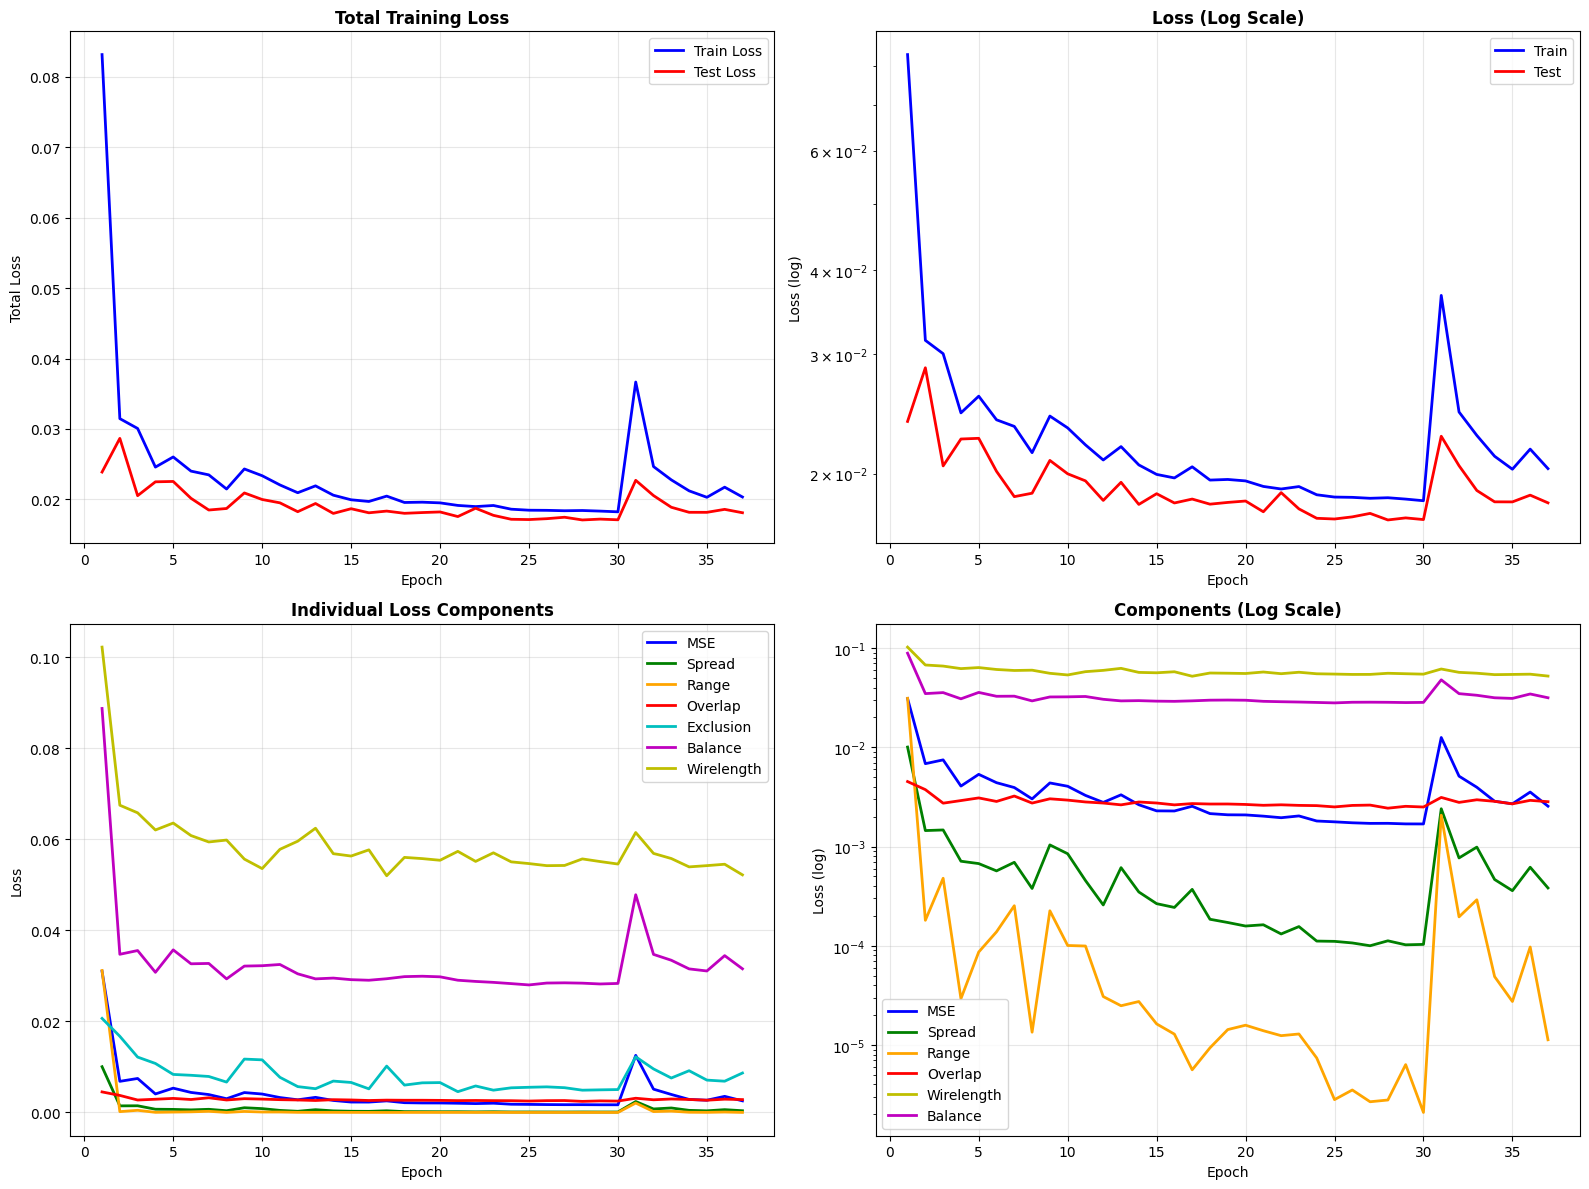

Final train: 0.020347 | Final test: 0.018112


In [12]:
# ================================================================
# TRAINING CURVES
# ================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax = axes[0, 0]
ax.plot(range(1, len(train_losses) + 1), train_losses, 'b-', label='Train Loss', linewidth=2)
ax.plot(range(1, len(test_losses) + 1), test_losses, 'r-', label='Test Loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Total Loss')
ax.set_title('Total Training Loss', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(range(1, len(train_losses) + 1), train_losses, 'b-', label='Train', linewidth=2)
ax.plot(range(1, len(test_losses) + 1), test_losses, 'r-', label='Test', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (log)')
ax.set_title('Loss (Log Scale)', fontweight='bold')
ax.legend()
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
if loss_components_history.get('mse'):
    ep = range(1, len(loss_components_history['mse']) + 1)
    ax.plot(ep, loss_components_history['mse'], 'b-', label='MSE', linewidth=2)
    ax.plot(ep, loss_components_history['spread'], 'g-', label='Spread', linewidth=2)
    ax.plot(ep, loss_components_history['range'], color='orange', label='Range', linewidth=2)
    if loss_components_history.get('overlap'):
        ax.plot(ep, loss_components_history['overlap'], 'r-', label='Overlap', linewidth=2)
    if loss_components_history.get('exclusion'):
        ax.plot(ep, loss_components_history['exclusion'], 'c-', label='Exclusion', linewidth=2)
    if loss_components_history.get('balance'):
        ax.plot(ep, loss_components_history['balance'], 'm-', label='Balance', linewidth=2)
    if loss_components_history.get('wirelength'):
        ax.plot(ep, loss_components_history['wirelength'], 'y-', label='Wirelength', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Individual Loss Components', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
if loss_components_history.get('mse'):
    ep = range(1, len(loss_components_history['mse']) + 1)
    ax.plot(ep, loss_components_history['mse'], 'b-', label='MSE', linewidth=2)
    ax.plot(ep, loss_components_history['spread'], 'g-', label='Spread', linewidth=2)
    ax.plot(ep, loss_components_history['range'], color='orange', label='Range', linewidth=2)
    if loss_components_history.get('overlap'):
        ax.plot(ep, loss_components_history['overlap'], 'r-', label='Overlap', linewidth=2)
    if loss_components_history.get('wirelength'):
        ax.plot(ep, loss_components_history['wirelength'], 'y-', label='Wirelength', linewidth=2)
    if loss_components_history.get('balance'):
        ax.plot(ep, loss_components_history['balance'], 'm-', label='Balance', linewidth=2)
    ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (log)')
ax.set_title('Components (Log Scale)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

if train_losses:
    print(f"Final train: {train_losses[-1]:.6f} | Final test: {test_losses[-1]:.6f}")

---

# STEP 11: Test Model Predictions

Run the trained model on a test sample and visualize results.

Cell sizes available: widths [0.4, 183.0] µm, heights [2.0, 250.0] µm
HIERARCHICAL LEGALIZATION (Macros → Large → Small)
   Hierarchical legalization for 50,000 cells...
   Macros: 4, Std cells: 49996
   Phase 1: Placing 4 macros...
   Macros placed in 0.01s
   Phase 2: Placing 49,996 std cells (size-ordered)...
   Legalization complete in 3.64s
   Std cell overlaps fixed: 22,290
   Macro blocked regions: 4


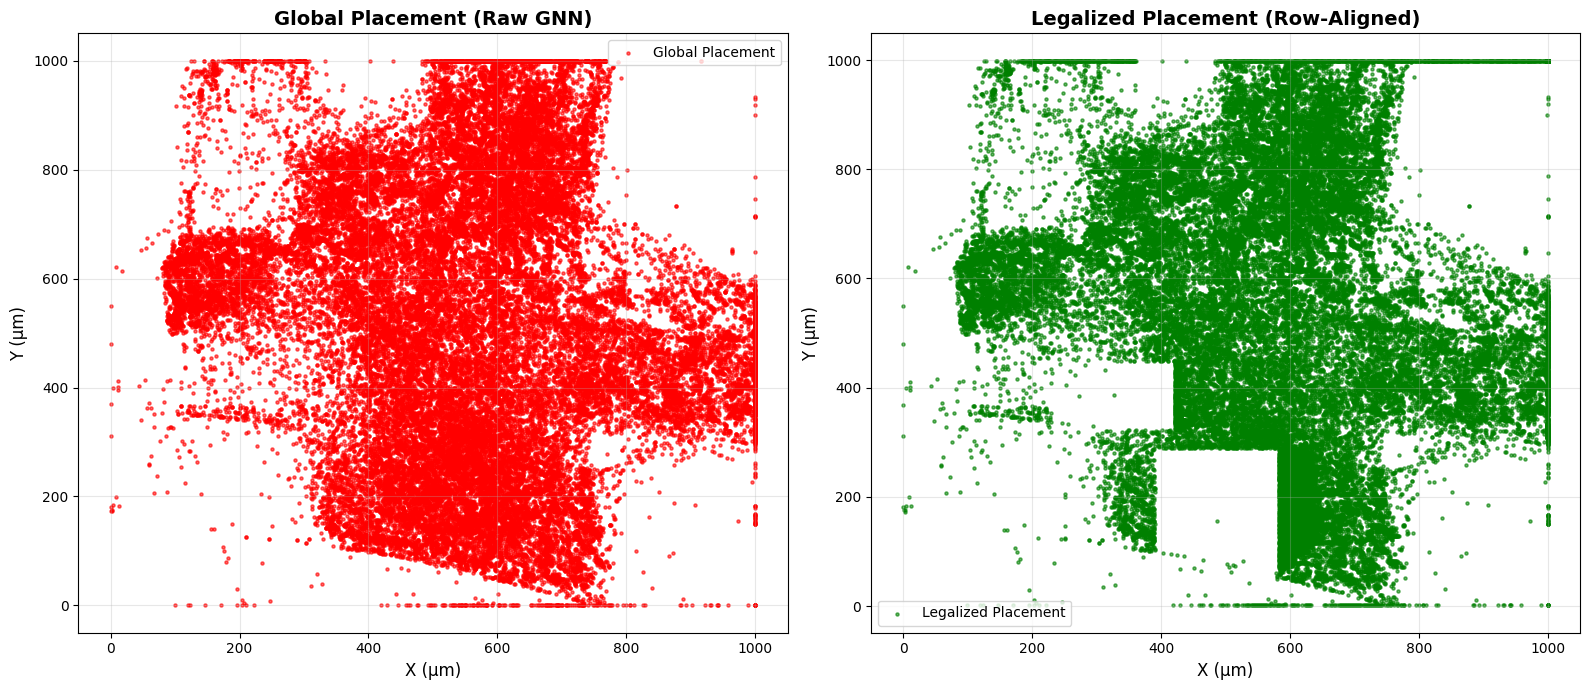


Legalization Impact:
   Average displacement: 17.52 µm
   Max displacement: 349.99 µm
   Cells moved: 48897/50000
   Cells placed in 504 rows

Sample: 201-mgc_edit_dist_a-util_0.7 (mgc_edit_dist_a)
Cells: 50,000 (4 macros)

Metric                           All     Macros        Std
----------------------------------------------------------
Mean error                  0.054368   0.204163   0.054356
Max error                   0.527023   0.391819   0.527023

Spread: X=0.89x, Y=0.94x


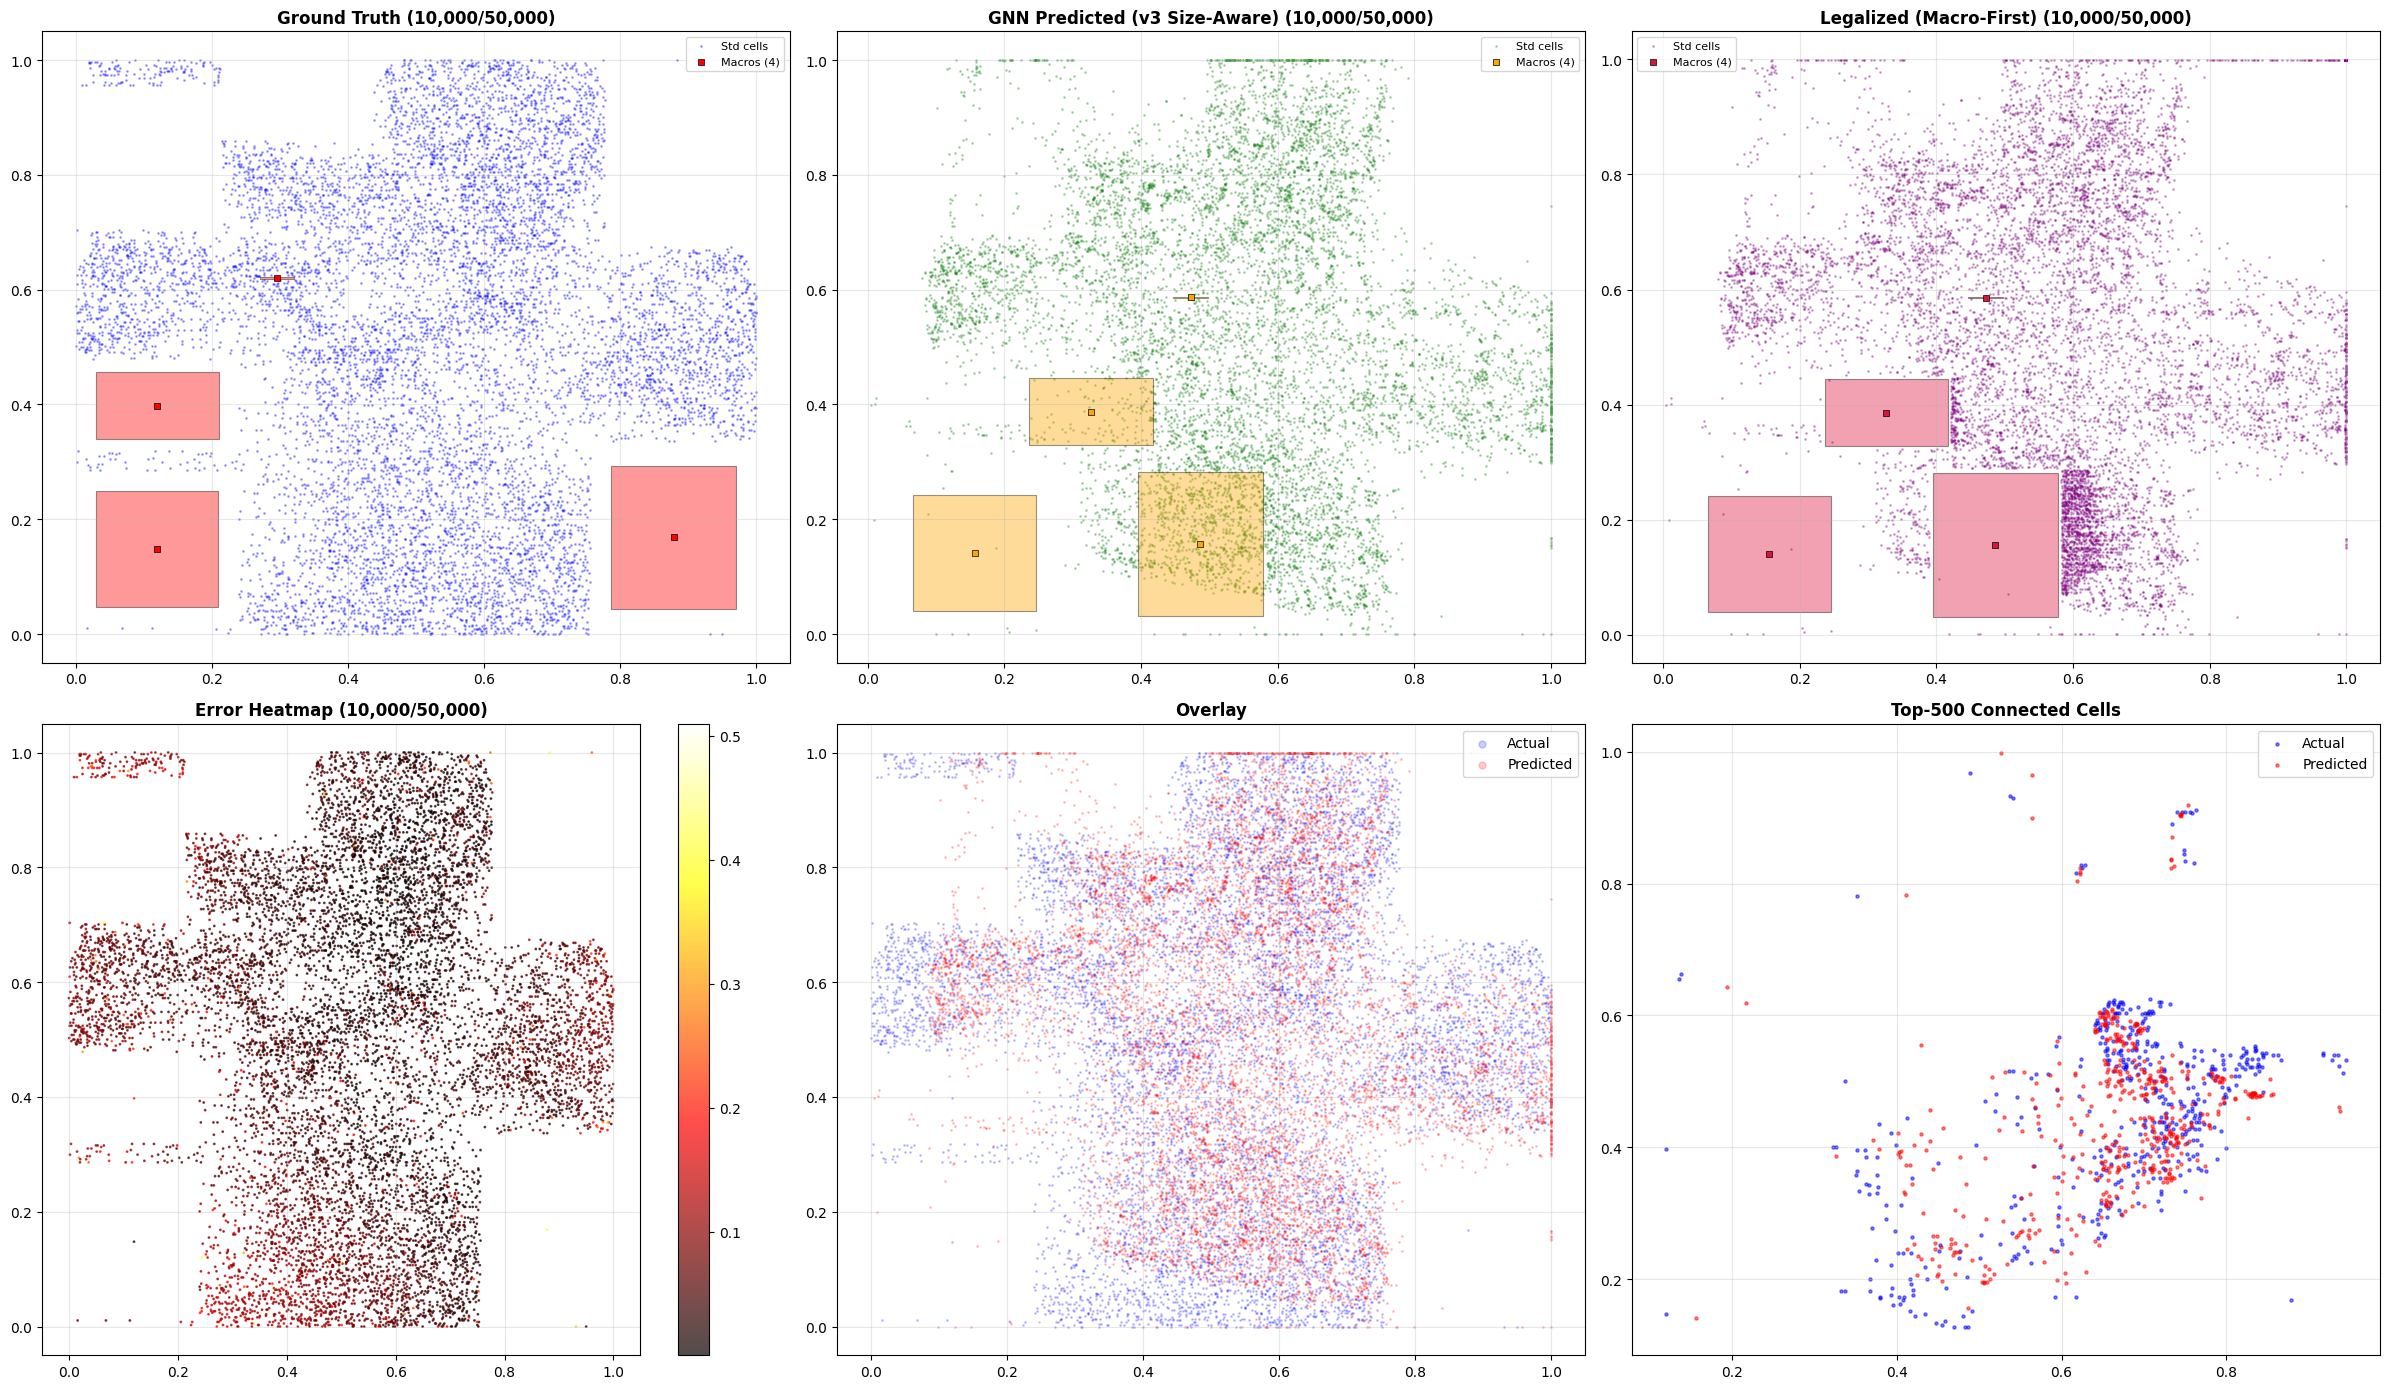

Step 11 done in 7.0s


In [13]:
import time
step11_start = time.time()

model.eval()
test_sample = cn_test[10].to(device)

with torch.no_grad():
    pred_coords = model(test_sample).cpu().numpy()

actual_coords = test_sample.y.cpu().numpy()
macro_mask = test_sample.is_macro.cpu().numpy() > 0.5
std_mask = ~macro_mask

# Get cell sizes (raw microns) — stored during data loading
if hasattr(test_sample, 'cell_widths') and hasattr(test_sample, 'cell_heights'):
    cw = test_sample.cell_widths.cpu().numpy()
    ch = test_sample.cell_heights.cpu().numpy()
    print(f"Cell sizes available: widths [{cw.min():.1f}, {cw.max():.1f}] µm, heights [{ch.min():.1f}, {ch.max():.1f}] µm")
else:
    cw = None
    ch = None
    print("Warning: cell sizes not available, using uniform sizes")

# Legalization with hierarchical macro-first placement
print("=" * 80)
print("HIERARCHICAL LEGALIZATION (Macros → Large → Small)")
print("=" * 80)

pred_microns = pred_coords * np.array([1000, 1000])
legalized_coords = legalize_placement(
    pred_microns, 
    chip_width_um=1000, chip_height_um=1000,
    cell_widths=cw, cell_heights=ch,
    is_macro=macro_mask
)
compare_global_vs_legal(pred_microns, legalized_coords, sample_name=test_sample.sample_name)

# Metrics
error = np.sqrt(np.sum((pred_coords - actual_coords) ** 2, axis=1))
macro_error = error[macro_mask] if macro_mask.any() else np.array([0])
std_error = error[std_mask]

print(f"\nSample: {test_sample.sample_name} ({test_sample.design_name})")
print(f"Cells: {test_sample.num_cells:,} ({macro_mask.sum()} macros)")
print(f"\n{'Metric':<25} {'All':>10} {'Macros':>10} {'Std':>10}")
print("-" * 58)
print(f"{'Mean error':<25} {np.mean(error):>10.6f} {np.mean(macro_error):>10.6f} {np.mean(std_error):>10.6f}")
print(f"{'Max error':<25} {np.max(error):>10.6f} {np.max(macro_error):>10.6f} {np.max(std_error):>10.6f}")

pred_std_x, pred_std_y = np.std(pred_coords[:, 0]), np.std(pred_coords[:, 1])
act_std_x, act_std_y = np.std(actual_coords[:, 0]), np.std(actual_coords[:, 1])
print(f"\nSpread: X={pred_std_x/act_std_x:.2f}x, Y={pred_std_y/act_std_y:.2f}x")

# Visualization with macro footprints
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection

n_total = len(actual_coords)
max_plot = 10000
if n_total > max_plot:
    # Always include ALL macros in the plot
    macro_idx_plot = np.where(macro_mask)[0]
    n_std_plot = max_plot - len(macro_idx_plot)
    std_idx_all = np.where(std_mask)[0]
    if len(std_idx_all) > n_std_plot:
        std_idx_plot = np.random.choice(std_idx_all, n_std_plot, replace=False)
    else:
        std_idx_plot = std_idx_all
    idx = np.concatenate([macro_idx_plot, std_idx_plot])
    actual_plot, pred_plot, error_plot = actual_coords[idx], pred_coords[idx], error[idx]
    legal_plot = legalized_coords[idx] / 1000
    macro_mask_plot = macro_mask[idx]
    cw_plot = cw[idx] / 1000 if cw is not None else None
    ch_plot = ch[idx] / 1000 if ch is not None else None
    note = f" ({max_plot:,}/{n_total:,})"
else:
    actual_plot, pred_plot, error_plot = actual_coords, pred_coords, error
    legal_plot = legalized_coords / 1000
    macro_mask_plot = macro_mask
    cw_plot = cw / 1000 if cw is not None else None
    ch_plot = ch / 1000 if ch is not None else None
    note = ""

def draw_with_macros(ax, coords, mask, widths, heights, title, std_color='blue', macro_color='red'):
    """Draw placement with macros shown as rectangles."""
    std_idx = ~mask
    ax.scatter(coords[std_idx, 0], coords[std_idx, 1], c=std_color, s=1, alpha=0.3, label='Std cells')
    if mask.any() and widths is not None:
        patches = []
        for i in np.where(mask)[0]:
            w, h = widths[i], heights[i]
            rect = Rectangle((coords[i, 0] - w/2, coords[i, 1] - h/2), w, h)
            patches.append(rect)
        if patches:
            pc = PatchCollection(patches, facecolor=macro_color, alpha=0.4, 
                                edgecolor='black', linewidth=0.8)
            ax.add_collection(pc)
            ax.scatter(coords[mask, 0], coords[mask, 1], c=macro_color, s=15, 
                      marker='s', edgecolors='black', linewidth=0.5, label=f'Macros ({mask.sum()})', zorder=5)
    elif mask.any():
        ax.scatter(coords[mask, 0], coords[mask, 1], c=macro_color, s=15, marker='s', label='Macros')
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(2, 3, figsize=(24, 14))

draw_with_macros(axes[0,0], actual_plot, macro_mask_plot, cw_plot, ch_plot,
                 f'Ground Truth{note}', 'blue', 'red')

draw_with_macros(axes[0,1], pred_plot, macro_mask_plot, cw_plot, ch_plot,
                 f'GNN Predicted (v3 Size-Aware){note}', 'forestgreen', 'orange')

draw_with_macros(axes[0,2], legal_plot, macro_mask_plot, cw_plot, ch_plot,
                 f'Legalized (Macro-First){note}', 'purple', 'crimson')

sc = axes[1,0].scatter(actual_plot[:,0], actual_plot[:,1], c=error_plot, cmap='hot', s=1, alpha=0.7)
axes[1,0].set_title(f'Error Heatmap{note}', fontweight='bold')
plt.colorbar(sc, ax=axes[1,0])

axes[1,1].scatter(actual_plot[:,0], actual_plot[:,1], c='blue', s=1, alpha=0.2, label='Actual')
axes[1,1].scatter(pred_plot[:,0], pred_plot[:,1], c='red', s=1, alpha=0.2, label='Predicted')
axes[1,1].set_title('Overlay', fontweight='bold')
axes[1,1].legend(markerscale=5)

conn_imp = test_sample.x[:, 15].cpu().numpy()
top_k = min(500, n_total)
top_idx = np.argsort(conn_imp)[-top_k:]
axes[1,2].scatter(actual_coords[top_idx,0], actual_coords[top_idx,1], c='blue', s=5, alpha=0.5, label='Actual')
axes[1,2].scatter(pred_coords[top_idx,0], pred_coords[top_idx,1], c='red', s=5, alpha=0.5, label='Predicted')
axes[1,2].set_title(f'Top-{top_k} Connected Cells', fontweight='bold')
axes[1,2].legend()

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Step 11 done in {time.time()-step11_start:.1f}s")

---

# Understanding the Placement Flow

## The Complete VLSI Placement Pipeline:

### 1. **Global Placement (GNN Model)**
- Input: Circuit netlist as graph
- Output: Continuous (x, y) coordinates in [0, 1] range
- Goal: Minimize wirelength, spread cells across chip
- **No physical constraints** - cells can overlap, float between rows

### 2. **Legalization (Post-Processing)**
- Input: Global placement coordinates
- Output: Legal, row-aligned coordinates
- Operations:
  - Scale to real chip dimensions (microns)
  - **Snap Y to rows** (remove vertical jitter)
  - **Snap X to sites** (align to placement grid)
  - **Remove overlaps** (cells cannot occupy same space)

### 3. **Detailed Placement (Not in this notebook)**
- Fine-tune positions within rows
- Optimize for timing, power, routability
- Usually done by commercial tools (Innovus, ICC)

---

## Why This Matters:

- **Raw GNN outputs are NOT legal placements** - they're global placement hints
- **DEF files require legalized coordinates** - EDA tools expect row-aligned, non-overlapping cells
- **Industry separation:** ML does global placement, algorithms do legalization
- **This notebook shows both:** Global placement quality + legalized output

---

In [14]:
# Save model (v3)
total_epochs = start_epoch + len(train_losses)

torch.save({
    'epoch': total_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'test_losses': test_losses,
    'loss_components': loss_components_history,
    'model_config': {
        'input_dim': 16,
        'hidden_dim': model.hidden_dim,
        'output_dim': 2,
        'num_layers': model.num_layers,
        'heads': 8,
        'version': 'v3'
    }
}, model_save)

print(f"Model saved to: {model_save}")
print(f"   Architecture: v3 (Multi-Scale GAT + Transformer)")
print(f"   Total epochs: {total_epochs}")
print(f"   File size: {os.path.getsize(model_save) / 1e6:.2f} MB")

Model saved to: C:\Users\Admin\VLSI-\Ayush\ispd15_placement_model.pth
   Architecture: v3 (Multi-Scale GAT + Transformer)
   Total epochs: 37
   File size: 29.19 MB


---

# STEP 12.5: Load Pre-trained Model & Test on Single Sample

Load a previously saved model and test it on a single sample.

Loading pre-trained model...

Model loaded! (v3, 37 epochs)
   Train loss: 0.020347
   Test loss: 0.018112

Test: 266-mgc_matrix_mult_b-util_0.8 (50,000 cells)
   Mean error: 0.065899
   Max error: 0.657433
   Macro error: 0.178694
   Spread: X=0.83x, Y=0.89x


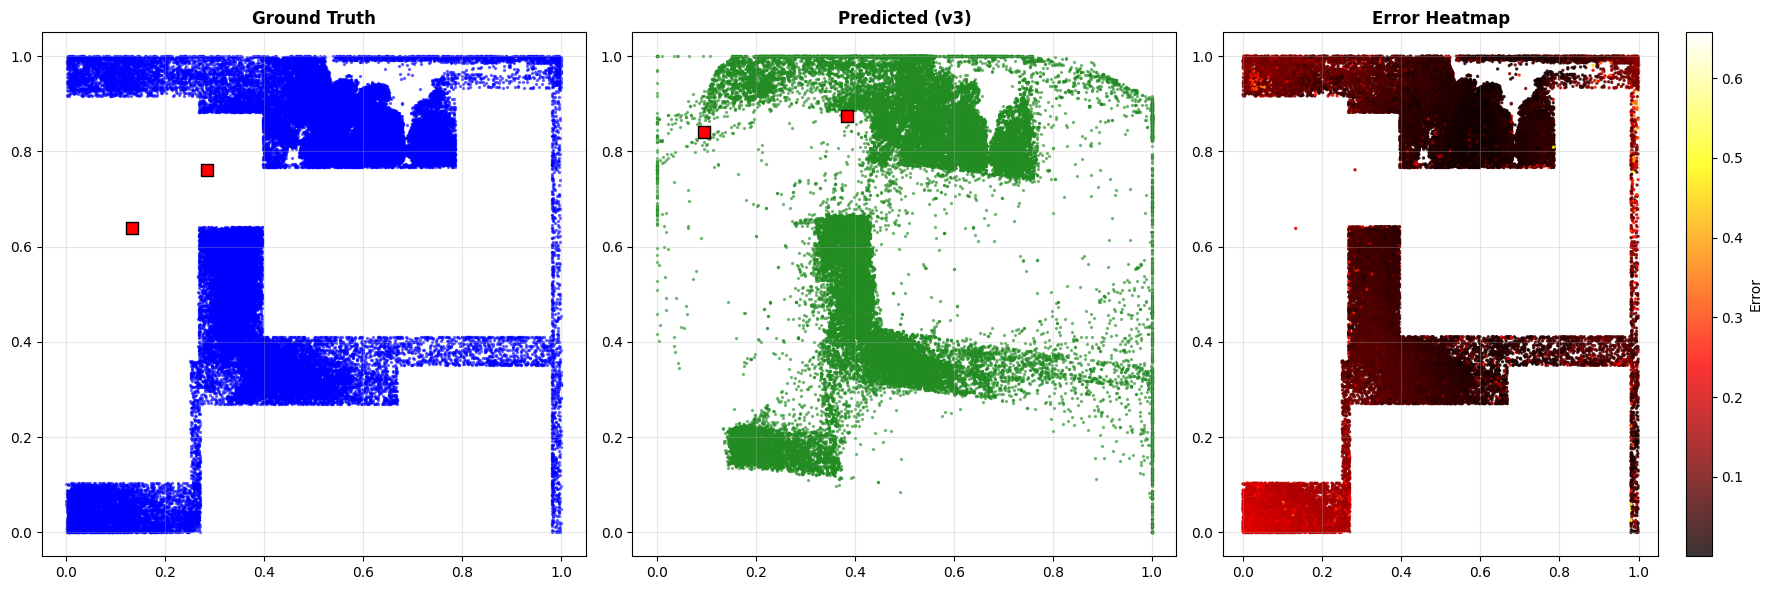

Test complete!


In [15]:
# Load and test model (v3)
print("Loading pre-trained model...\n")

model_load_path = model_save

if not os.path.exists(model_load_path):
    print(f"ERROR: Model not found at {model_load_path}")
    print("Train the model first!")
else:
    checkpoint = torch.load(model_load_path, map_location=device)
    config = checkpoint.get('model_config', {})
    version = config.get('version', 'v1')
    
    loaded_model = VLSIPlacementGNN(
        input_dim=config.get('input_dim', 16),
        hidden_dim=config.get('hidden_dim', 256),
        output_dim=config.get('output_dim', 2),
        num_layers=config.get('num_layers', 6),
        heads=config.get('heads', 8)
    ).to(device)
    
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model.eval()
    
    print(f"Model loaded! ({version}, {checkpoint['epoch']} epochs)")
    print(f"   Train loss: {checkpoint['train_losses'][-1]:.6f}")
    print(f"   Test loss: {checkpoint['test_losses'][-1]:.6f}")
    
    # Test on a sample
    test_idx = min(len(cn_test) - 1, 5)
    test_sample = cn_test[test_idx].to(device)
    
    print(f"\nTest: {test_sample.sample_name} ({test_sample.num_cells:,} cells)")
    
    with torch.no_grad():
        pred_coords = loaded_model(test_sample).cpu().numpy()
    
    actual_coords = test_sample.y.cpu().numpy()
    macro_mask = test_sample.is_macro.cpu().numpy() > 0.5
    error = np.sqrt(np.sum((pred_coords - actual_coords) ** 2, axis=1))
    
    print(f"   Mean error: {np.mean(error):.6f}")
    print(f"   Max error: {np.max(error):.6f}")
    if macro_mask.any():
        print(f"   Macro error: {np.mean(error[macro_mask]):.6f}")
    
    pred_std = np.std(pred_coords, axis=0)
    act_std = np.std(actual_coords, axis=0)
    print(f"   Spread: X={pred_std[0]/act_std[0]:.2f}x, Y={pred_std[1]/act_std[1]:.2f}x")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].scatter(actual_coords[:, 0], actual_coords[:, 1], c='blue', s=2, alpha=0.5)
    if macro_mask.any():
        axes[0].scatter(actual_coords[macro_mask, 0], actual_coords[macro_mask, 1],
                       c='red', s=80, marker='s', edgecolors='black', zorder=5)
    axes[0].set_title('Ground Truth', fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].scatter(pred_coords[:, 0], pred_coords[:, 1], c='forestgreen', s=2, alpha=0.5)
    if macro_mask.any():
        axes[1].scatter(pred_coords[macro_mask, 0], pred_coords[macro_mask, 1],
                       c='red', s=80, marker='s', edgecolors='black', zorder=5)
    axes[1].set_title(f'Predicted ({version})', fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    scatter = axes[2].scatter(actual_coords[:, 0], actual_coords[:, 1],
                             c=error, cmap='hot', s=2, alpha=0.8)
    axes[2].set_title('Error Heatmap', fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[2], label='Error')
    
    plt.tight_layout()
    plt.savefig('loaded_model_test.png', dpi=100, bbox_inches='tight')
    plt.show()
    print("Test complete!")

In [16]:
# Per-design evaluation breakdown
print("Per-Design Evaluation\n")

model.eval()
design_results = defaultdict(list)

with torch.no_grad():
    for data in cn_test:
        data_d = data.to(device)
        pred = model(data_d).cpu().numpy()
        actual = data.y.numpy()
        error = np.mean(np.sqrt(np.sum((pred - actual) ** 2, axis=1)))
        design_results[data.design_name].append({
            'error': error, 'cells': data.num_cells
        })

print(f"{'Design':<30} {'Samples':>8} {'Avg Cells':>10} {'Avg Error':>10}")
print("-" * 62)
for design in sorted(design_results.keys()):
    results = design_results[design]
    avg_err = np.mean([r['error'] for r in results])
    avg_cells = int(np.mean([r['cells'] for r in results]))
    print(f"{design:<30} {len(results):>8} {avg_cells:>10,} {avg_err:>10.6f}")

Per-Design Evaluation



TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [ ]:
print(f"Train: {len(cn_train)} | Test: {len(cn_test)} | Total: {len(circuitnet_dataset)}")

---

# STEP 13: Industry-Grade Visualization

Create production-quality layout visualization with micron precision.

In [ ]:
def visualize_industry_layout(data, predictions, chip_width_microns=1000, chip_height_microns=1000, dpi=150):
    """
    Industry-grade layout visualization with micron precision
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), dpi=dpi)
    
    # Convert normalized coordinates to microns
    predicted_microns = predictions * np.array([chip_width_microns, chip_height_microns])
    actual_microns = data.y.cpu().numpy() * np.array([chip_width_microns, chip_height_microns])
    
    # Plot 1: Predicted Layout
    ax1 = axes[0]
    ax1.set_xlim(0, chip_width_microns)
    ax1.set_ylim(0, chip_height_microns)
    ax1.set_aspect('equal')
    ax1.set_facecolor('#1a1a1a')
    
    # Draw cells with different colors based on size
    for i, (x, y) in enumerate(predicted_microns):
        # Estimate cell size from node features (simplified)
        cell_width = max(5, min(50, data.x[i, 3].item() * 20)) if data.x.shape[1] > 3 else 10
        cell_height = cell_width * 0.8
        
        rect = Rectangle((x - cell_width/2, y - cell_height/2), 
                        cell_width, cell_height,
                        facecolor='cyan', edgecolor='white', 
                        alpha=0.7, linewidth=0.5)
        ax1.add_patch(rect)
    
    # Draw connections (sample)
    edge_index = data.edge_index.cpu().numpy()
    for i in range(0, min(500, edge_index.shape[1]), 5):  # Sample edges
        src, dst = edge_index[:, i]
        ax1.plot([predicted_microns[src, 0], predicted_microns[dst, 0]],
                [predicted_microns[src, 1], predicted_microns[dst, 1]],
                'yellow', alpha=0.2, linewidth=0.3)
    
    ax1.set_title('Predicted Layout (Micron Precision)', fontsize=14, color='white', pad=20)
    ax1.set_xlabel('X Position (µm)', fontsize=12, color='white')
    ax1.set_ylabel('Y Position (µm)', fontsize=12, color='white')
    ax1.tick_params(colors='white')
    ax1.grid(True, alpha=0.2, color='gray')
    
    # Plot 2: Actual Layout
    ax2 = axes[1]
    ax2.set_xlim(0, chip_width_microns)
    ax2.set_ylim(0, chip_height_microns)
    ax2.set_aspect('equal')
    ax2.set_facecolor('#1a1a1a')
    
    for i, (x, y) in enumerate(actual_microns):
        cell_width = max(5, min(50, data.x[i, 3].item() * 20)) if data.x.shape[1] > 3 else 10
        cell_height = cell_width * 0.8
        
        rect = Rectangle((x - cell_width/2, y - cell_height/2), 
                        cell_width, cell_height,
                        facecolor='lime', edgecolor='white', 
                        alpha=0.7, linewidth=0.5)
        ax2.add_patch(rect)
    
    # Draw connections
    for i in range(0, min(500, edge_index.shape[1]), 5):
        src, dst = edge_index[:, i]
        ax2.plot([actual_microns[src, 0], actual_microns[dst, 0]],
                [actual_microns[src, 1], actual_microns[dst, 1]],
                'yellow', alpha=0.2, linewidth=0.3)
    
    ax2.set_title('Actual Layout (Ground Truth)', fontsize=14, color='white', pad=20)
    ax2.set_xlabel('X Position (µm)', fontsize=12, color='white')
    ax2.set_ylabel('Y Position (µm)', fontsize=12, color='white')
    ax2.tick_params(colors='white')
    ax2.grid(True, alpha=0.2, color='gray')
    
    plt.tight_layout()
    plt.savefig('industry_layout.png', dpi=dpi, facecolor='#1a1a1a')
    plt.show()
    
    # Calculate metrics
    mse = np.mean((predicted_microns - actual_microns) ** 2)
    mae = np.mean(np.abs(predicted_microns - actual_microns))
    
    print(f"\nLayout Accuracy Metrics:")
    print(f"   Mean Squared Error: {mse:.2f} µm²")
    print(f"   Mean Absolute Error: {mae:.2f} µm")
    print(f"   Average X Error: {np.mean(np.abs(predicted_microns[:, 0] - actual_microns[:, 0])):.2f} µm")
    print(f"   Average Y Error: {np.mean(np.abs(predicted_microns[:, 1] - actual_microns[:, 1])):.2f} µm")

# Visualize with test data
print("Creating industry-grade layout visualization...")
model.eval()
with torch.no_grad():
    test_data = cn_test[min(len(cn_test)-1, 2)].to(device)
    test_pred = model(test_data).cpu().numpy()

visualize_industry_layout(test_data, test_pred)
print("Industry-grade visualization complete!")

---

# STEP 14: Wirelength Optimization

Calculate and optimize total wirelength using Half-Perimeter Wire Length (HPWL).

In [ ]:
def calculate_wirelength(data, predictions):
    """
    Calculate total wirelength using Half-Perimeter Wire Length (HPWL)
    """
    print("Calculating wirelength metrics...")
    
    edge_index = data.edge_index.cpu().numpy()
    
    # Group edges by nets (simplified: each edge is a 2-pin net)
    wirelengths = []
    
    for i in range(edge_index.shape[1]):
        src, dst = edge_index[:, i]
        x1, y1 = predictions[src]
        x2, y2 = predictions[dst]
        
        # Manhattan distance (L1 norm)
        manhattan = abs(x2 - x1) + abs(y2 - y1)
        
        # Euclidean distance (L2 norm)
        euclidean = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        
        wirelengths.append({
            'manhattan': manhattan,
            'euclidean': euclidean,
            'src': src,
            'dst': dst
        })
    
    # Calculate statistics
    total_manhattan = sum(w['manhattan'] for w in wirelengths)
    total_euclidean = sum(w['euclidean'] for w in wirelengths)
    avg_manhattan = np.mean([w['manhattan'] for w in wirelengths])
    avg_euclidean = np.mean([w['euclidean'] for w in wirelengths])
    
    # Visualize wirelength distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    ax1 = axes[0]
    manhattan_lengths = [w['manhattan'] for w in wirelengths]
    ax1.hist(manhattan_lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    ax1.axvline(avg_manhattan, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_manhattan:.4f}')
    ax1.set_xlabel('Wire Length (Manhattan)', fontsize=12)
    ax1.set_ylabel('Frequency', fontsize=12)
    ax1.set_title('Wirelength Distribution', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Cumulative distribution
    ax2 = axes[1]
    sorted_lengths = np.sort(manhattan_lengths)
    cumulative = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths)
    ax2.plot(sorted_lengths, cumulative, linewidth=2, color='green')
    ax2.set_xlabel('Wire Length (Manhattan)', fontsize=12)
    ax2.set_ylabel('Cumulative Probability', fontsize=12)
    ax2.set_title('Cumulative Wirelength Distribution', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('wirelength_analysis.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Print results
    print(f"\nWirelength Analysis Results:")
    print(f"   Total wires: {len(wirelengths)}")
    print(f"   Total Manhattan wirelength: {total_manhattan:.4f}")
    print(f"   Total Euclidean wirelength: {total_euclidean:.4f}")
    print(f"   Average Manhattan length: {avg_manhattan:.4f}")
    print(f"   Average Euclidean length: {avg_euclidean:.4f}")
    print(f"   Maximum wire length: {max(manhattan_lengths):.4f}")
    print(f"   Minimum wire length: {min(manhattan_lengths):.4f}")
    print(f"   Std deviation: {np.std(manhattan_lengths):.4f}")
    
    # Find longest wires
    longest_wires = sorted(wirelengths, key=lambda x: x['manhattan'], reverse=True)[:5]
    print(f"\nTop 5 Longest Wires:")
    for idx, wire in enumerate(longest_wires, 1):
        print(f"   {idx}. Node {wire['src']} → Node {wire['dst']}: {wire['manhattan']:.4f}")
    
    return wirelengths, total_manhattan

# Calculate wirelength
model.eval()
with torch.no_grad():
    test_data = cn_test[0].to(device)
    test_pred = model(test_data).cpu().numpy()

wirelengths, total_wl = calculate_wirelength(test_data, test_pred)
print("\nWirelength optimization complete!")

---

# STEP 15: Multi-Sample Evaluation

Evaluate model performance across multiple test samples.

In [ ]:
# Evaluate on all test samples
print("Evaluating model on all test samples...\n")

all_results = []
model.eval()

with torch.no_grad():
    for idx, data in enumerate(cn_test):
        data = data.to(device)
        pred = model(data).cpu().numpy()
        actual = data.y.cpu().numpy()
        
        # Calculate metrics
        mse = np.mean((pred - actual) ** 2)
        mae = np.mean(np.abs(pred - actual))
        max_error = np.max(np.abs(pred - actual))
        
        all_results.append({
            'sample': data.sample_name,
            'num_cells': data.num_cells,
            'mse': mse,
            'mae': mae,
            'max_error': max_error
        })
        
        if (idx + 1) % 5 == 0:
            print(f"   Evaluated {idx+1}/{len(cn_test)} samples...")

print(f"\nEvaluation complete!\n")

# Aggregate statistics
avg_mse = np.mean([r['mse'] for r in all_results])
avg_mae = np.mean([r['mae'] for r in all_results])
avg_max_error = np.mean([r['max_error'] for r in all_results])

print("Overall Model Performance:")
print(f"   Average MSE: {avg_mse:.6f}")
print(f"   Average MAE: {avg_mae:.6f}")
print(f"   Average Max Error: {avg_max_error:.6f}")

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# MSE distribution
ax1 = axes[0, 0]
mse_values = [r['mse'] for r in all_results]
ax1.hist(mse_values, bins=20, color='blue', edgecolor='black', alpha=0.7)
ax1.axvline(avg_mse, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_mse:.6f}')
ax1.set_xlabel('MSE', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('MSE Distribution Across Test Samples', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# MAE distribution
ax2 = axes[0, 1]
mae_values = [r['mae'] for r in all_results]
ax2.hist(mae_values, bins=20, color='green', edgecolor='black', alpha=0.7)
ax2.axvline(avg_mae, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_mae:.6f}')
ax2.set_xlabel('MAE', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('MAE Distribution Across Test Samples', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Error vs. Circuit Size
ax3 = axes[1, 0]
sizes = [r['num_cells'] for r in all_results]
ax3.scatter(sizes, mae_values, alpha=0.6, s=50, color='purple')
ax3.set_xlabel('Number of Cells', fontsize=12)
ax3.set_ylabel('MAE', fontsize=12)
ax3.set_title('Placement Error vs. Circuit Size', fontsize=14)
ax3.grid(True, alpha=0.3)

# Per-sample performance
ax4 = axes[1, 1]
sample_indices = range(len(all_results))
ax4.plot(sample_indices, mse_values, 'o-', label='MSE', alpha=0.7)
ax4.plot(sample_indices, mae_values, 's-', label='MAE', alpha=0.7)
ax4.set_xlabel('Sample Index', fontsize=12)
ax4.set_ylabel('Error', fontsize=12)
ax4.set_title('Per-Sample Performance', fontsize=14)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('multi_sample_evaluation.png', dpi=100, bbox_inches='tight')
plt.show()

# Best and worst samples
best_sample = min(all_results, key=lambda x: x['mae'])
worst_sample = max(all_results, key=lambda x: x['mae'])

print(f"\nBest Sample:")
print(f"   Name: {best_sample['sample']}")
print(f"   Cells: {best_sample['num_cells']:,}")
print(f"   MAE: {best_sample['mae']:.6f}")

print(f"\nWorst Sample:")
print(f"   Name: {worst_sample['sample']}")
print(f"   Cells: {worst_sample['num_cells']:,}")
print(f"   MAE: {worst_sample['mae']:.6f}")

print("\nMulti-sample evaluation complete!")

---

# STEP 16: Export Results

Export placement results and statistics to files for EDA tool integration.

In [ ]:
import json
import csv
import numpy as np

# Custom JSON encoder to handle numpy types
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (np.integer,)):
            return int(obj)
        if isinstance(obj, (np.floating,)):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

# Create output directory
output_dir = output_dir
os.makedirs(output_dir, exist_ok=True)

print("Exporting results...\n")

# 1. Export placement predictions for a sample
test_sample = cn_test[0]
model.eval()
with torch.no_grad():
    test_sample_device = test_sample.to(device)
    predictions = model(test_sample_device).cpu().numpy()

# Export to JSON
placement_data = {
    'design_name': test_sample.design_name,
    'sample_name': test_sample.sample_name,
    'num_cells': int(test_sample.num_cells),
    'predictions': []
}

for i in range(len(predictions)):
    placement_data['predictions'].append({
        'cell_id': i,
        'x': float(predictions[i, 0]),
        'y': float(predictions[i, 1]),
        'x_actual': float(test_sample.y[i, 0]),
        'y_actual': float(test_sample.y[i, 1])
    })

json_path = os.path.join(output_dir, f"{test_sample.sample_name}_placement.json")
with open(json_path, 'w') as f:
    json.dump(placement_data, f, indent=2, cls=NumpyEncoder)

print(f"[OK] Exported placement to: {json_path}")

# 2. Export DEF-like format (simplified)
def_path = os.path.join(output_dir, f"{test_sample.sample_name}_placement.def")
with open(def_path, 'w') as f:
    f.write(f"DESIGN {test_sample.design_name} ;\n")
    f.write(f"COMPONENTS {test_sample.num_cells} ;\n")
    
    for i in range(len(predictions)):
        # Convert normalized coords to micron (assuming 1000x1000 um chip)
        x_um = int(predictions[i, 0] * 1000)
        y_um = int(predictions[i, 1] * 1000)
        f.write(f"  - CELL_{i} + PLACED ( {x_um} {y_um} ) N ;\n")
    
    f.write("END COMPONENTS\n")

print(f"[OK] Exported DEF format to: {def_path}")

# 3. Export evaluation metrics
metrics_data = {
    'model_info': {
        'input_dim': 16,
        'hidden_dim': 128,
        'output_dim': 2,
        'num_layers': 4,
        'heads': 4,
        'total_parameters': sum(p.numel() for p in model.parameters())
    },
    'training_info': {
        'num_epochs': NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'final_train_loss': float(train_losses[-1]),
        'final_test_loss': float(test_losses[-1]),
        'num_train_samples': len(cn_train),
        'num_test_samples': len(cn_test)
    },
    'test_results': all_results
}

metrics_path = os.path.join(output_dir, "model_metrics.json")
with open(metrics_path, 'w') as f:
    json.dump(metrics_data, f, indent=2, cls=NumpyEncoder)

print(f"[OK] Exported metrics to: {metrics_path}")

# 4. Export CSV summary
csv_path = os.path.join(output_dir, "test_results_summary.csv")
with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['sample', 'num_cells', 'mse', 'mae', 'max_error'])
    writer.writeheader()
    writer.writerows(all_results)

print(f"[OK] Exported CSV summary to: {csv_path}")

# 5. Export training history
history_path = os.path.join(output_dir, "training_history.csv")
with open(history_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'train_loss', 'test_loss'])
    for epoch in range(NUM_EPOCHS):
        writer.writerow([epoch + 1, train_losses[epoch], test_losses[epoch]])

print(f"[OK] Exported training history to: {history_path}")

print(f"\nAll results exported to: {output_dir}")
print("\nExport complete!")

---

# STEP 17: Run GNN Placement Inference via GUI

Browse and select your **standard VLSI design files** — the GNN predicts cell placement from scratch:
- **Verilog Netlist** (`.v`) — cell instances, nets, connectivity *(required)*
- **LEF Library** (`.lef`) — cell dimensions & pin definitions *(required)*
- **Model checkpoint** (`.pth`) — trained GNN weights *(required)*
- **SDC file** (`.sdc`) — timing constraints *(optional)*
- **Floorplan DEF** (`.def`) — die area & IO pad positions only, NOT cell placement *(optional)*

The cell parses these files, converts them into the 16-feature graph, and the **GNN predicts placement coordinates from scratch**.

In [ ]:
import tkinter as tk
from tkinter import filedialog, messagebox, ttk
import re
import json

# ═══════════════════════════════════════════════════════════════════
# PARSERS: Standard VLSI files → GNN-compatible format
# ═══════════════════════════════════════════════════════════════════

def parse_verilog_netlist(verilog_path):
    """
    Parse a gate-level Verilog netlist (.v) to extract cell instances,
    net connections, and pin-level connectivity.
    
    Handles instantiations like:
      NAND2X1 u123 ( .A(n45), .B(n67), .Y(n89) );
    
    Returns:
      node_attr: [cell_names, cell_types]
      pin_attr: [nets, cells, pins]  (nets as list of pin lists)
      cell_names: list of instance names
      cell_types: list of cell types
    """
    with open(verilog_path, 'r') as f:
        content = f.read()
    
    # Remove comments
    content = re.sub(r'//.*', '', content)
    content = re.sub(r'/\*.*?\*/', '', content, flags=re.DOTALL)
    
    # Extract module name
    module_match = re.search(r'module\s+(\w+)', content)
    module_name = module_match.group(1) if module_match else "design"
    
    # Extract cell instances (gate instantiations)
    # Pattern: CellType InstName ( .pin(net), .pin(net), ... );
    inst_pattern = r'(\w+)\s+(\w+)\s*\((.*?)\)\s*;'
    instances = []
    
    for match in re.finditer(inst_pattern, content, re.DOTALL):
        cell_type = match.group(1)
        inst_name = match.group(2)
        pins_str = match.group(3)
        
        # Skip module declaration, input/output wires
        if cell_type.lower() in ['module', 'input', 'output', 'wire', 'assign']:
            continue
        
        # Parse pin connections: .A(net1), .B(net2)
        pin_pattern = r'\.(\w+)\s*\(\s*(\w+)\s*\)'
        pins = {}
        for pm in re.finditer(pin_pattern, pins_str):
            pin_name = pm.group(1)
            net_name = pm.group(2)
            pins[pin_name] = net_name
        
        instances.append({
            'name': inst_name,
            'type': cell_type,
            'pins': pins
        })
    
    if not instances:
        raise ValueError(f"No cell instances found in {verilog_path}. Check Verilog syntax.")
    
    cell_names = [inst['name'] for inst in instances]
    cell_types = [inst['type'] for inst in instances]
    
    # Build net-to-pins mapping for connectivity
    net_to_pins = {}
    for inst in instances:
        for pin_name, net_name in inst['pins'].items():
            if net_name not in net_to_pins:
                net_to_pins[net_name] = []
            net_to_pins[net_name].append((inst['name'], pin_name))
    
    # Convert to pin_attr format matching CircuitNet expectations
    # pin_attr[0] = pin name (string)
    # pin_attr[1] = net index (int) - which net this pin belongs to
    # pin_attr[2] = node index (int) - which cell this pin belongs to
    
    # Create mappings
    nets = sorted(net_to_pins.keys())  # List of net names
    net_to_idx = {net: i for i, net in enumerate(nets)}  # net name -> net index
    cell_to_idx = {name: i for i, name in enumerate(cell_names)}  # cell name -> cell index
    
    pin_attr_data = [[], [], []]
    
    for net_name, pins_on_net in net_to_pins.items():
        net_idx = net_to_idx[net_name]
        for cell_name, pin_name in pins_on_net:
            cell_idx = cell_to_idx[cell_name]
            pin_attr_data[0].append(pin_name)      # pin name (string)
            pin_attr_data[1].append(net_idx)       # net index (int)
            pin_attr_data[2].append(cell_idx)      # cell/node index (int)
    
    pin_attr = np.array(pin_attr_data, dtype=object)
    node_attr = np.array([cell_names, cell_types], dtype=object)
    
    print(f"   [Verilog] {len(cell_names)} cells, {len(cell_types)} types, {len(nets)} nets")
    return node_attr, pin_attr, cell_names, cell_types


def parse_lef_file(lef_path):
    """
    Parse LEF file to extract cell dimensions (width, height).
    Returns: cell_type -> {width, height, class, pins}
    """
    with open(lef_path, 'r') as f:
        content = f.read()
    
    cell_lib = {}
    
    # Match MACRO blocks
    macro_pattern = r'MACRO\s+(\w+)\s+(.*?)END\s+\1'
    for match in re.finditer(macro_pattern, content, re.DOTALL | re.IGNORECASE):
        cell_name = match.group(1)
        cell_block = match.group(2)
        
        # Extract SIZE dimensions
        size_match = re.search(r'SIZE\s+([\d.]+)\s+BY\s+([\d.]+)', cell_block, re.IGNORECASE)
        if size_match:
            width = float(size_match.group(1))
            height = float(size_match.group(2))
        else:
            width, height = 1.0, 1.0
        
        # Extract CLASS
        class_match = re.search(r'CLASS\s+(\w+)', cell_block, re.IGNORECASE)
        cell_class = class_match.group(1) if class_match else "CORE"
        
        # Count pins
        pin_count = len(re.findall(r'PIN\s+\w+', cell_block, re.IGNORECASE))
        
        cell_lib[cell_name] = {
            'width': width, 'height': height,
            'class': cell_class, 'pins': pin_count
        }
    
    print(f"   [LEF] {len(cell_lib)} cell definitions extracted")
    return cell_lib


def parse_floorplan_def(def_path):
    """
    Parse DEF floorplan file to extract die area and fixed IO pads ONLY.
    Does NOT extract cell placements (GNN predicts those).
    """
    with open(def_path, 'r') as f:
        content = f.read()
    
    # Extract DIEAREA
    die_area = None
    die_match = re.search(r'DIEAREA\s*\(\s*(-?\d+)\s+(-?\d+)\s*\)\s*\(\s*(-?\d+)\s+(-?\d+)\s*\)', content)
    if die_match:
        die_area = (
            int(die_match.group(1)), int(die_match.group(2)),
            int(die_match.group(3)), int(die_match.group(4))
        )
    
    # Extract FIXED IO pads only (not PLACED cells)
    io_pads = {}
    comp_match = re.search(r'COMPONENTS\s+\d+\s*;(.*?)END\s+COMPONENTS', content, re.DOTALL)
    if comp_match:
        fixed_pattern = re.compile(
            r'-\s+(\S+)\s+(\S+)\s*.*?FIXED\s*\(\s*(-?\d+)\s+(-?\d+)\s*\)',
            re.DOTALL
        )
        for m in fixed_pattern.finditer(comp_match.group(1)):
            io_pads[m.group(1)] = (int(m.group(3)), int(m.group(4)))
    
    print(f"   [DEF Floorplan] Die area: {die_area}, {len(io_pads)} fixed IO pads")
    return die_area, io_pads


def parse_sdc_file(sdc_path):
    """Parse SDC timing constraints."""
    with open(sdc_path, 'r') as f:
        lines = f.readlines()
    
    constraints = {
        'clock_period': 10.0, 'clock_name': 'clk',
        'input_delays': {}, 'output_delays': {},
        'max_fanout': 10, 'max_transition': 0.5
    }
    
    for line in lines:
        clock_match = re.search(r'create_clock.*-period\s+([\d.]+).*\[get_ports\s+(\w+)\]', line)
        if clock_match:
            constraints['clock_period'] = float(clock_match.group(1))
            constraints['clock_name'] = clock_match.group(2)
        
        in_delay = re.search(r'set_input_delay\s+.*?([\\d.]+).*?\[get_ports\s+(\S+)\]', line)
        if in_delay:
            constraints['input_delays'][in_delay.group(2)] = float(in_delay.group(1))
        
        out_delay = re.search(r'set_output_delay\s+.*?([\\d.]+).*?\[get_ports\s+(\S+)\]', line)
        if out_delay:
            constraints['output_delays'][out_delay.group(2)] = float(out_delay.group(1))
        fanout_match = re.search(r'set_max_fanout\s+([\\d.]+)', line)
        if fanout_match:
            constraints['max_fanout'] = int(float(fanout_match.group(1)))
        trans_match = re.search(r'set_max_transition\s+([\\d.]+)', line)
        if trans_match:
            constraints['max_transition'] = float(trans_match.group(1))
    
    print(f"   [SDC] Clock: {constraints['clock_name']} @ {constraints['clock_period']}ns")
    return constraints


# ═══════════════════════════════════════════════════════════════════
# CONVERTER: Parsed files → 16-feature GNN Data (NO prior placement)
# ═══════════════════════════════════════════════════════════════════

def convert_to_gnn_data_from_netlist(node_attr, pin_attr, cell_lib,
                                      die_area=None, io_pads=None,
                                      sdc_constraints=None):
    """
    Convert parsed Verilog + LEF into the 16-feature PyTorch Geometric Data
    that VLSIPlacementGNN expects.
    
    NO prior placement is used — initial positions are derived from cell
    ordering and connectivity (force-directed initialization).
    
    The GNN will predict the actual (x,y) placement.
    """
    cell_names = list(node_attr[0])
    cell_types = list(node_attr[1])
    num_nodes = len(cell_names)
    
    # ── Determine chip dimensions ──
    if die_area:
        chip_w = die_area[2] - die_area[0]
        chip_h = die_area[3] - die_area[1]
    else:
        # Estimate from total cell area (assume 60% utilization)
        total_cell_area = 0
        for ct in cell_types:
            if ct in cell_lib:
                total_cell_area += cell_lib[ct]['width'] * cell_lib[ct]['height']
        if total_cell_area > 0:
            chip_w = chip_h = np.sqrt(total_cell_area / 0.6)
        else:
            chip_w = chip_h = 1000.0  # Default 1mm × 1mm
    
    # ── Cell sizes from LEF ──
    sizes = np.zeros((num_nodes, 2), dtype=np.float32)
    areas = np.zeros(num_nodes, dtype=np.float32)
    for i, ct in enumerate(cell_types):
        if ct in cell_lib:
            sizes[i, 0] = cell_lib[ct]['width']
            sizes[i, 1] = cell_lib[ct]['height']
        else:
            sizes[i] = [1.0, 1.0]
        areas[i] = sizes[i, 0] * sizes[i, 1]
    
    total_chip_area = chip_w * chip_h + 1e-8
    sizes_norm = sizes / (sizes.max() + 1e-8)
    
    # ── Check chip feasibility ──
    total_cell_area_actual = areas.sum()
    utilization = total_cell_area_actual / total_chip_area
    print(f"\n   ⚠️  CHIP UTILIZATION CHECK:")
    print(f"      Chip area: {chip_w:.1f} × {chip_h:.1f} = {total_chip_area:.1f} µm²")
    print(f"      Total cell area: {total_cell_area_actual:.1f} µm²")
    print(f"      Utilization: {utilization*100:.1f}%")
    
    if utilization > 1.0:
        print(f"      ❌ ERROR: Cells cannot physically fit! ({utilization*100:.0f}% > 100%)")
        print(f"      → Chip too small or too many/large cells")
        print(f"      → Minimum chip size needed: {np.sqrt(total_cell_area_actual/0.8):.0f}×{np.sqrt(total_cell_area_actual/0.8):.0f} µm (80% util)")
        raise ValueError(f"Infeasible placement: chip utilization = {utilization*100:.0f}%")
    elif utilization > 0.85:
        print(f"      ⚠️  WARNING: Very high density! Placement quality may be poor.")
    elif utilization < 0.2:
        print(f"      ℹ️  Low utilization - cells will be spread out")
    else:
        print(f"      ✓ Feasible chip size")
    
    # ── Build edges from netlist connectivity ──
    edge_index, n_orphans, n_nets, cell_connectivity = build_netlist_edges(
        pin_attr, node_attr, cell_names, star_threshold=10
    )
    
    has_netlist = edge_index.shape[1] > 0
    
    if not has_netlist:
        print("   WARNING: No netlist edges, using sequential chain fallback")
        src = np.arange(0, num_nodes - 1, dtype=np.int64)
        dst = np.arange(1, num_nodes, dtype=np.int64)
        edge_index = np.stack([
            np.concatenate([src, dst]),
            np.concatenate([dst, src])
        ], axis=0)
        for idx in range(num_nodes):
            cell_connectivity[idx] = {'pin_count': 0, 'net_count': 0,
                                       'avg_fanout': 0, 'max_fanout': 0}
    
    # ── Initial positions: spread cells across chip area ──
    # Use a simple grid layout as initialization (GNN will predict final)
    grid_cols = max(1, int(np.ceil(np.sqrt(num_nodes * chip_w / chip_h))))
    grid_rows = max(1, int(np.ceil(num_nodes / grid_cols)))
    
    coords = np.zeros((num_nodes, 2), dtype=np.float32)
    for i in range(num_nodes):
        row = i // grid_cols
        col = i % grid_cols
        coords[i, 0] = (col + 0.5) / grid_cols * chip_w
        coords[i, 1] = (row + 0.5) / grid_rows * chip_h
    
    # Place fixed IO pads at their known positions
    if io_pads:
        for pad_name, (px, py) in io_pads.items():
            if pad_name in cell_names:
                idx = cell_names.index(pad_name)
                coords[idx] = [px, py]
    
    # Normalize coordinates to [0, 1]
    coord_min = coords.min(axis=0)
    coord_range = coords.max(axis=0) - coord_min + 1e-8
    coords_norm = (coords - coord_min) / coord_range
    
    # ── Cell classification ──
    is_macro = np.zeros(num_nodes, dtype=np.float32)
    cell_category_arr = np.zeros(num_nodes, dtype=np.float32)
    type_encoding = np.zeros(num_nodes, dtype=np.float32)
    
    unique_types = sorted(set(cell_types))
    type_to_idx = {t: i for i, t in enumerate(unique_types)}
    if len(unique_types) > 1:
        type_encoding = np.array([type_to_idx[t] for t in cell_types], dtype=np.float32) / (len(unique_types) - 1)
    
    for i, (ct, a) in enumerate(zip(cell_types, areas)):
        macro, filler, cat = classify_cell(ct, a)
        is_macro[i] = float(macro)
        cell_category_arr[i] = cat / 3.0
    
    # ── Connectivity features ──
    pin_counts = np.array([cell_connectivity.get(i, {}).get('pin_count', 0) for i in range(num_nodes)], dtype=np.float32)
    net_counts = np.array([cell_connectivity.get(i, {}).get('net_count', 0) for i in range(num_nodes)], dtype=np.float32)
    avg_fanouts = np.array([cell_connectivity.get(i, {}).get('avg_fanout', 0) for i in range(num_nodes)], dtype=np.float32)
    max_fanouts = np.array([cell_connectivity.get(i, {}).get('max_fanout', 0) for i in range(num_nodes)], dtype=np.float32)
    
    pin_counts_norm = pin_counts / (pin_counts.max() + 1e-8)
    net_counts_norm = net_counts / (net_counts.max() + 1e-8)
    avg_fanouts_norm = avg_fanouts / (avg_fanouts.max() + 1e-8)
    max_fanouts_norm = max_fanouts / (max_fanouts.max() + 1e-8)
    
    # ── Additional features ──
    relative_area = areas / total_chip_area
    relative_area_norm = relative_area / (relative_area.max() + 1e-8)
    
    aspect_ratio = sizes[:, 0] / (sizes[:, 1] + 1e-8)
    aspect_ratio = np.clip(aspect_ratio, 0, 10)
    aspect_ratio_norm = aspect_ratio / (aspect_ratio.max() + 1e-8)
    
    conn_importance = pin_counts * net_counts
    conn_importance_norm = conn_importance / (conn_importance.max() + 1e-8)
    
    neighbor_area_avg = np.zeros(num_nodes, dtype=np.float32)
    if edge_index.shape[1] > 0:
        ei = edge_index
        for e in range(ei.shape[1]):
            s, d = ei[0, e], ei[1, e]
            neighbor_area_avg[s] += areas[d]
        degree = np.bincount(ei[0], minlength=num_nodes).astype(np.float32)
        degree[degree == 0] = 1
        neighbor_area_avg /= degree
    neighbor_area_norm = neighbor_area_avg / (neighbor_area_avg.max() + 1e-8)
    
    # ── Assemble 16-feature vector (same as training) ──
    node_features = np.zeros((num_nodes, 16), dtype=np.float32)
    node_features[:, 0]  = coords_norm[:, 0]       # [0] x position (initial)
    node_features[:, 1]  = coords_norm[:, 1]       # [1] y position (initial)
    node_features[:, 2]  = sizes_norm[:, 0]         # [2] width
    node_features[:, 3]  = sizes_norm[:, 1]         # [3] height
    node_features[:, 4]  = np.log1p(areas)          # [4] log area
    node_features[:, 4] /= (node_features[:, 4].max() + 1e-8)
    node_features[:, 5]  = type_encoding            # [5] cell type
    node_features[:, 6]  = is_macro                 # [6] is_macro
    node_features[:, 7]  = cell_category_arr        # [7] cell category
    node_features[:, 8]  = pin_counts_norm          # [8] pin count
    node_features[:, 9]  = net_counts_norm          # [9] net count
    node_features[:, 10] = avg_fanouts_norm         # [10] avg fanout
    node_features[:, 11] = max_fanouts_norm         # [11] max fanout
    node_features[:, 12] = relative_area_norm       # [12] relative area
    node_features[:, 13] = aspect_ratio_norm        # [13] aspect ratio
    node_features[:, 14] = neighbor_area_norm       # [14] avg neighbor size
    node_features[:, 15] = conn_importance_norm     # [15] connectivity importance
    
    # ── Build Data object ──
    data = Data(
        x=torch.tensor(node_features, dtype=torch.float),
        edge_index=torch.tensor(edge_index, dtype=torch.long),
        y=torch.zeros(num_nodes, 2)   # no ground truth — GNN predicts this
    )
    data.num_cells = num_nodes
    data.sample_name = "user_design"
    data.design_name = "user_design"
    data.original_coords = torch.tensor(coords, dtype=torch.float)
    data.is_macro = torch.tensor(is_macro, dtype=torch.float)
    data.areas = torch.tensor(areas, dtype=torch.float)
    data.cell_names = cell_names
    data.cell_types = cell_types
    data.chip_w = chip_w
    data.chip_h = chip_h
    
    print(f"\n   Converted to GNN format:")
    print(f"      Cells: {num_nodes:,}")
    print(f"      Edges: {edge_index.shape[1]:,}")
    print(f"      Macros: {int(is_macro.sum())}")
    print(f"      Features: 16 per cell")
    
    return data


# ═══════════════════════════════════════════════════════════════════════
# GUI: Browse files → Parse → GNN Inference → Legalize → Visualize
# ═══════════════════════════════════════════════════════════════════════

def run_gnn_inference_gui():
    """
    Tkinter GUI to:
      1. Browse for Verilog, LEF (required), Model (required),
         and optionally SDC, Floorplan DEF
      2. Parse all files → build 16-feature graph
      3. Run GNN inference (predicted placement)
      4. Legalize placement (snap to rows/sites)
      5. Export DEF + JSON and visualize
    """
    file_paths = {
        'verilog': None, 'lef': None, 'model': None,
        'sdc': None, 'def': None,
    }
    
    root = tk.Tk()
    root.title("VLSI GNN Placement — Inference from Netlist")
    root.geometry("750x580")
    root.configure(bg='#1e1e2e')
    root.resizable(False, False)
    
    style = ttk.Style()
    style.theme_use('clam')
    style.configure('H.TLabel', background='#1e1e2e', foreground='#cdd6f4',
                    font=('Segoe UI', 15, 'bold'))
    style.configure('Sub.TLabel', background='#1e1e2e', foreground='#a6adc8',
                    font=('Segoe UI', 9))
    style.configure('B.TButton', font=('Segoe UI', 9))
    
    ttk.Label(root, text="VLSI GNN Placement Inference", style='H.TLabel').pack(pady=(16, 2))
    ttk.Label(root, text="GNN predicts placement from Verilog + LEF — no existing placement needed.",
              style='Sub.TLabel').pack(pady=(0, 12))
    
    file_frame = tk.Frame(root, bg='#1e1e2e')
    file_frame.pack(fill='x', padx=28)
    
    path_vars = {}
    
    file_defs = [
        ('verilog', 'Verilog Netlist (.v)',     [('Verilog', '*.v'), ('All', '*.*')],     True),
        ('lef',     'LEF Cell Library (.lef)',   [('LEF', '*.lef'), ('All', '*.*')],       True),
        ('model',   'Model Weights (.pth)',      [('PyTorch', '*.pth'), ('All', '*.*')],   True),
        ('sdc',     'SDC Constraints (.sdc)',    [('SDC', '*.sdc'), ('All', '*.*')],        False),
        ('def',     'Floorplan DEF (.def)',      [('DEF', '*.def'), ('All', '*.*')],        False),
    ]
    
    for key, label_text, ftypes, required in file_defs:
        row = tk.Frame(file_frame, bg='#1e1e2e')
        row.pack(fill='x', pady=3)
        
        tag = " *" if required else ""
        tk.Label(row, text=f"{label_text}{tag}", bg='#1e1e2e', fg='#cdd6f4',
                 font=('Segoe UI', 10), width=28, anchor='w').pack(side='left')
        
        pv = tk.StringVar(value="No file selected")
        tk.Label(row, textvariable=pv, bg='#313244', fg='#bac2de',
                 font=('Consolas', 9), width=38, anchor='w',
                 relief='flat', padx=6, pady=3).pack(side='left', padx=(4, 6))
        path_vars[key] = pv
        
        def make_browse(k=key, ft=ftypes, v=pv):
            def browse():
                p = filedialog.askopenfilename(filetypes=ft)
                if p:
                    file_paths[k] = p
                    v.set(os.path.basename(p))
            return browse
        
        ttk.Button(row, text="Browse", command=make_browse(), style='B.TButton').pack(side='left')
    
    ttk.Label(file_frame, text="* = required      (DEF is for die area / IO pads only — NOT cell placement)",
              style='Sub.TLabel').pack(anchor='w', pady=(6, 0))
    
    status_var = tk.StringVar(value="Ready — select files and click Run Inference")
    tk.Label(root, textvariable=status_var, bg='#1e1e2e', fg='#a6e3a1',
             font=('Segoe UI', 10), wraplength=680, justify='left').pack(
        pady=(14, 4), padx=28, anchor='w')
    
    progress = ttk.Progressbar(root, mode='determinate', length=690)
    progress.pack(pady=(2, 10), padx=28)
    
    def run_inference():
        # Validate required files
        for key in ['verilog', 'lef', 'model']:
            if not file_paths[key]:
                nice = {'verilog': 'Verilog Netlist', 'lef': 'LEF Library',
                        'model': 'Model Weights'}[key]
                messagebox.showerror("Missing File", f"Please select a {nice} file.")
                return
        
        progress['value'] = 0
        root.update_idletasks()
        
        try:
            # ── Step 1: Parse Verilog ──
            status_var.set("Step 1/6 — Parsing Verilog netlist...")
            progress['value'] = 8; root.update_idletasks()
            node_attr, pin_attr, cell_names, cell_types = parse_verilog_netlist(
                file_paths['verilog'])
            
            # ── Step 2: Parse LEF ──
            status_var.set("Step 2/6 — Parsing LEF cell library...")
            progress['value'] = 20; root.update_idletasks()
            cell_lib = parse_lef_file(file_paths['lef'])
            
            # ── Step 3: Parse Floorplan DEF (optional) ──
            die_area, io_pads = None, None
            if file_paths['def']:
                status_var.set("Step 3/6 — Parsing floorplan DEF (die area + IO pads)...")
                progress['value'] = 28; root.update_idletasks()
                die_area, io_pads = parse_floorplan_def(file_paths['def'])
            
            # ── Step 4: Parse SDC (optional) ──
            sdc_constraints = None
            if file_paths['sdc']:
                status_var.set("Step 4/6 — Parsing SDC constraints...")
                progress['value'] = 32; root.update_idletasks()
                sdc_constraints = parse_sdc_file(file_paths['sdc'])
            
            # ── Step 5: Convert to GNN format ──
            status_var.set("Step 5/6 — Building 16-feature graph...")
            progress['value'] = 40; root.update_idletasks()
            
            gnn_data = convert_to_gnn_data_from_netlist(
                node_attr, pin_attr, cell_lib,
                die_area=die_area, io_pads=io_pads,
                sdc_constraints=sdc_constraints
            )
            
            # ═══════════════════════════════════════════════════════════════
            # SHOW EXTRACTED FEATURES — Display what GNN will receive
            # ═══════════════════════════════════════════════════════════════
            progress['value'] = 45; root.update_idletasks()
            
            # Create feature display window
            feature_window = tk.Toplevel(root)
            feature_window.title("Extracted Features — GNN Input Data")
            feature_window.geometry("900x700")
            feature_window.configure(bg='#1e1e2e')
            feature_window.transient(root)
            feature_window.grab_set()
            
            # Main container with scrollbar
            main_frame = tk.Frame(feature_window, bg='#1e1e2e')
            main_frame.pack(fill='both', expand=True, padx=15, pady=15)
            
            # Canvas + Scrollbar
            canvas = tk.Canvas(main_frame, bg='#1e1e2e', highlightthickness=0)
            scrollbar = tk.Scrollbar(main_frame, orient="vertical", command=canvas.yview)
            scrollable_frame = tk.Frame(canvas, bg='#1e1e2e')
            
            scrollable_frame.bind(
                "<Configure>",
                lambda e: canvas.configure(scrollregion=canvas.bbox("all"))
            )
            
            canvas.create_window((0, 0), window=scrollable_frame, anchor="nw")
            canvas.configure(yscrollcommand=scrollbar.set)
            
            # Title
            tk.Label(scrollable_frame, text="📊 Extracted Features from Input Files", 
                    bg='#1e1e2e', fg='#89b4fa', 
                    font=('Segoe UI', 16, 'bold')).pack(pady=(0, 10))
            
            tk.Label(scrollable_frame, text="Features below will be input to the GNN model for placement prediction",
                    bg='#1e1e2e', fg='#a6adc8', 
                    font=('Segoe UI', 9, 'italic')).pack(pady=(0, 15))
            
            # ── Section 1: FROM VERILOG NETLIST ──
            tk.Label(scrollable_frame, text="━" * 85, bg='#1e1e2e', fg='#45475a',
                    font=('Courier', 8)).pack()
            tk.Label(scrollable_frame, text="📄 FROM VERILOG NETLIST (.v)", 
                    bg='#1e1e2e', fg='#f9e2af', 
                    font=('Segoe UI', 12, 'bold')).pack(anchor='w', pady=(8, 5))
            
            verilog_info = f"""   ✓ Cell instances: {len(cell_names):,} cells
   ✓ Cell types: {len(set(cell_types))} unique types  (e.g., {', '.join(list(set(cell_types))[:5])})
   ✓ Nets: {len(set(pin_attr[0])) if pin_attr is not None else 0:,} connections parsed
   ✓ Connectivity: Pin-to-net mapping extracted
   
   → Extracted Features:
      [5]  Cell type encoding
      [6]  Is macro flag (PLL, SRAM detection)
      [7]  Cell category (filler/combo/seq/macro)
      [8]  Pin count per cell
      [9]  Net count per cell
      [10] Average net fanout
      [11] Maximum net fanout
      [15] Connectivity importance (pins × nets)"""
            
            tk.Label(scrollable_frame, text=verilog_info, 
                    bg='#1e1e2e', fg='#cdd6f4', 
                    font=('Consolas', 9), justify='left').pack(anchor='w', padx=20)
            
            # ── Section 2: FROM LEF FILE ──
            tk.Label(scrollable_frame, text="━" * 85, bg='#1e1e2e', fg='#45475a',
                    font=('Courier', 8)).pack(pady=(15, 0))
            tk.Label(scrollable_frame, text="📐 FROM LEF LIBRARY (.lef)", 
                    bg='#1e1e2e', fg='#a6e3a1', 
                    font=('Segoe UI', 12, 'bold')).pack(anchor='w', pady=(8, 5))
            
            lef_info = f"""   ✓ Cell library: {len(cell_lib)} cell definitions
   ✓ Physical dimensions extracted for each cell type
   ✓ Sample cells: {', '.join(list(cell_lib.keys())[:4])}...
   
   → Extracted Features:
      [2]  Width (from LEF SIZE statement)
      [3]  Height (from LEF SIZE statement)
      [4]  Log area (calculated: width × height)
      [12] Relative area (cell area / chip area)
      [13] Aspect ratio (width / height)"""
            
            tk.Label(scrollable_frame, text=lef_info, 
                    bg='#1e1e2e', fg='#cdd6f4', 
                    font=('Consolas', 9), justify='left').pack(anchor='w', padx=20)
            
            # ── Section 3: COMPUTED FEATURES ──
            tk.Label(scrollable_frame, text="━" * 85, bg='#1e1e2e', fg='#45475a',
                    font=('Courier', 8)).pack(pady=(15, 0))
            tk.Label(scrollable_frame, text="🧮 COMPUTED FEATURES", 
                    bg='#1e1e2e', fg='#cba6f7', 
                    font=('Segoe UI', 12, 'bold')).pack(anchor='w', pady=(8, 5))
            
            computed_info = f"""   ✓ Initial positions: Grid layout initialization
   ✓ Neighbor context: Average size of connected cells
   
   → Extracted Features:
      [0]  X position (grid-based initialization)
      [1]  Y position (grid-based initialization)
      [14] Average neighbor size (from connectivity graph)"""
            
            tk.Label(scrollable_frame, text=computed_info, 
                    bg='#1e1e2e', fg='#cdd6f4', 
                    font=('Consolas', 9), justify='left').pack(anchor='w', padx=20)
            
            # ── Section 4: COMPLETE 16-FEATURE VECTOR ──
            tk.Label(scrollable_frame, text="━" * 85, bg='#1e1e2e', fg='#45475a',
                    font=('Courier', 8)).pack(pady=(15, 0))
            tk.Label(scrollable_frame, text="🎯 COMPLETE 16-FEATURE VECTOR (Input to GNN)", 
                    bg='#1e1e2e', fg='#f38ba8', 
                    font=('Segoe UI', 12, 'bold')).pack(anchor='w', pady=(8, 5))
            
            # Get features for first 5 cells
            num_cells_to_show = min(5, gnn_data.num_cells)
            
            feature_names = [
                "[0]  X position (initial)",
                "[1]  Y position (initial)", 
                "[2]  Cell width",
                "[3]  Cell height",
                "[4]  Log area (normalized)",
                "[5]  Cell type (encoded)",
                "[6]  Is macro (0/1)",
                "[7]  Cell category (0-1)",
                "[8]  Pin count",
                "[9]  Net count",
                "[10] Avg net fanout",
                "[11] Max net fanout",
                "[12] Relative area",
                "[13] Aspect ratio",
                "[14] Avg neighbor size",
                "[15] Connectivity importance"
            ]
            
            sources = [
                "Computed", "Computed", "LEF", "LEF", "LEF+Calc",
                "Verilog", "Verilog", "Verilog", "Verilog", "Verilog",
                "Verilog", "Verilog", "LEF+Calc", "LEF+Calc", "Graph+LEF", "Verilog+Calc"
            ]
            
            feature_table = f"   Showing first {num_cells_to_show} cells (out of {gnn_data.num_cells} total)\n\n"
            
            for cell_idx in range(num_cells_to_show):
                sample_features = gnn_data.x[cell_idx].cpu().numpy()
                is_macro_flag = "🔴 MACRO" if gnn_data.is_macro[cell_idx] > 0.5 else "🔵 STD"
                
                feature_table += f"\n   {'-'*80}\n"
                feature_table += f"   CELL #{cell_idx+1}: '{gnn_data.cell_names[cell_idx]}' (type: {gnn_data.cell_types[cell_idx]}) {is_macro_flag}\n"
                feature_table += f"   {'-'*80}\n\n"
                feature_table += f"   {'Feature':<35} {'Value':>10}  {'Source'}\n"
                feature_table += f"   {'─'*35} {'─'*10}  {'─'*20}\n"
                
                for i, (fname, fval, src) in enumerate(zip(feature_names, sample_features, sources)):
                    feature_table += f"   {fname:<35} {fval:>10.4f}  {src}\n"
                
                feature_table += "\n"
            
            tk.Label(scrollable_frame, text=feature_table, 
                    bg='#1e1e2e', fg='#cdd6f4', 
                    font=('Consolas', 8), justify='left').pack(anchor='w', padx=20)
            
            # ── Section 5: GRAPH STATISTICS ──
            tk.Label(scrollable_frame, text="━" * 85, bg='#1e1e2e', fg='#45475a',
                    font=('Courier', 8)).pack(pady=(15, 0))
            tk.Label(scrollable_frame, text="📈 GRAPH STATISTICS", 
                    bg='#1e1e2e', fg='#74c7ec', 
                    font=('Segoe UI', 12, 'bold')).pack(anchor='w', pady=(8, 5))
            
            n_macros = int(gnn_data.is_macro.sum())
            avg_degree = gnn_data.edge_index.shape[1] / gnn_data.num_cells
            
            stats_info = f"""   Total Cells: {gnn_data.num_cells:,}
   Macros: {n_macros} ({n_macros/gnn_data.num_cells*100:.1f}%)
   Standard Cells: {gnn_data.num_cells - n_macros:,} ({(gnn_data.num_cells-n_macros)/gnn_data.num_cells*100:.1f}%)
   
   Graph Connectivity:
   • Edges: {gnn_data.edge_index.shape[1]:,} directed edges
   • Average degree: {avg_degree:.1f} connections per cell
   • Chip dimensions: {gnn_data.chip_w:.1f} × {gnn_data.chip_h:.1f} µm
   
   ✓ All 16 features extracted successfully!
   ✓ Ready for GNN inference"""
            
            tk.Label(scrollable_frame, text=stats_info, 
                    bg='#1e1e2e', fg='#cdd6f4', 
                    font=('Consolas', 9), justify='left').pack(anchor='w', padx=20, pady=(0, 10))
            
            # Continue button
            def close_feature_window():
                feature_window.destroy()
            
            tk.Label(scrollable_frame, text="━" * 85, bg='#1e1e2e', fg='#45475a',
                    font=('Courier', 8)).pack(pady=(10, 15))
            
            tk.Button(scrollable_frame, text="✓ Continue to GNN Inference", 
                     command=close_feature_window,
                     bg='#89b4fa', fg='#1e1e2e', font=('Segoe UI', 11, 'bold'),
                     relief='flat', padx=40, pady=10, cursor='hand2',
                     activebackground='#74c7ec').pack(pady=(5, 15))
            
            canvas.pack(side="left", fill="both", expand=True)
            scrollbar.pack(side="right", fill="y")
            
            # Wait for user to close the window
            root.wait_window(feature_window)
            
            # ── Step 6: Load model & run inference ──
            status_var.set("Step 6/6 — Loading model & running GNN inference...")
            progress['value'] = 55; root.update_idletasks()
            
            inference_model = VLSIPlacementGNN(
                input_dim=16, hidden_dim=128, output_dim=2,
                num_layers=4, heads=4
            ).to(device)
            
            ckpt = torch.load(file_paths['model'], map_location=device)
            inference_model.load_state_dict(ckpt['model_state_dict'])
            inference_model.eval()
            
            # Keep CPU copies of tensors we need for visualization BEFORE .to(device)
            is_macro_cpu = gnn_data.is_macro.clone().cpu()
            edge_index_cpu = gnn_data.edge_index.clone().cpu()
            
            with torch.no_grad():
                gnn_data_dev = gnn_data.to(device)
                predictions = inference_model(gnn_data_dev).cpu().numpy()
            
            progress['value'] = 75; root.update_idletasks()
            
            # ── Scale predictions to real chip coordinates ──
            chip_w = gnn_data.chip_w
            chip_h = gnn_data.chip_h
            pred_coords = predictions * np.array([chip_w, chip_h])
            
            # ── Legalize placement ──
            status_var.set("Legalizing placement (row/site snapping)...")
            progress['value'] = 82; root.update_idletasks()
            
            legalized = legalize_placement(
                pred_coords, chip_width_um=chip_w, chip_height_um=chip_h
            )
            
            # ── Save results ──
            status_var.set("Saving results...")
            progress['value'] = 90; root.update_idletasks()
            
            output_dir = os.path.dirname(file_paths['verilog'])
            
            # Output DEF (the whole point — GNN-generated placement)
            def_out = os.path.join(output_dir, "gnn_predicted_placement.def")
            with open(def_out, 'w') as f:
                f.write("VERSION 5.8 ;\n")
                if die_area:
                    f.write(f"DIEAREA ( {die_area[0]} {die_area[1]} )"
                            f" ( {die_area[2]} {die_area[3]} ) ;\n")
                f.write(f"DESIGN {gnn_data.design_name} ;\n\n")
                f.write(f"COMPONENTS {gnn_data.num_cells} ;\n")
                for idx in range(len(legalized)):
                    x_int = int(legalized[idx, 0])
                    y_int = int(legalized[idx, 1])
                    f.write(f"  - {gnn_data.cell_names[idx]} {gnn_data.cell_types[idx]}"
                            f" + PLACED ( {x_int} {y_int} ) N ;\n")
                f.write("END COMPONENTS\n\nEND DESIGN\n")
            
            # Output JSON
            json_out = os.path.join(output_dir, "gnn_predicted_placement.json")
            result = {
                'design': gnn_data.design_name,
                'num_cells': int(gnn_data.num_cells),
                'chip_width': float(chip_w),
                'chip_height': float(chip_h),
                'cells': [
                    {
                        'name': gnn_data.cell_names[i],
                        'type': gnn_data.cell_types[i],
                        'predicted_x': float(legalized[i, 0]),
                        'predicted_y': float(legalized[i, 1]),
                        'global_x': float(pred_coords[i, 0]),
                        'global_y': float(pred_coords[i, 1]),
                    }
                    for i in range(len(legalized))
                ]
            }
            with open(json_out, 'w') as f:
                json.dump(result, f, indent=2)
            
            progress['value'] = 100
            status_var.set(f"Done! Saved: {os.path.basename(def_out)}, {os.path.basename(json_out)}")
            root.update_idletasks()
            
            # ── Close GUI → visualize in matplotlib ──
            root.destroy()
            
            print("\n" + "=" * 70)
            print("GNN PLACEMENT INFERENCE COMPLETE")
            print("=" * 70)
            print(f"   Cells: {gnn_data.num_cells:,}")
            print(f"   Chip:  {chip_w:.1f} x {chip_h:.1f}")
            print(f"   DEF:   {def_out}")
            print(f"   JSON:  {json_out}")
            print("=" * 70)
            
            # Plot: Global vs Legalized  (use CPU copies saved earlier)
            fig, axes = plt.subplots(1, 2, figsize=(16, 8), dpi=120)
            fig.patch.set_facecolor('#1a1a1a')
            
            macro_mask = is_macro_cpu.numpy().astype(bool)
            
            for ax, coords_plot, title, color in [
                (axes[0], pred_coords, 'GNN Global Placement (Raw)', 'cyan'),
                (axes[1], legalized,  'Legalized Placement (Row-Aligned)', 'lime'),
            ]:
                ax.set_facecolor('#1a1a1a')
                ax.scatter(coords_plot[~macro_mask, 0], coords_plot[~macro_mask, 1],
                          s=3, c=color, alpha=0.6, label='Standard cells')
                if macro_mask.any():
                    ax.scatter(coords_plot[macro_mask, 0], coords_plot[macro_mask, 1],
                              s=40, c='red', marker='s', alpha=0.9, label='Macros')
                
                # Sample edges
                ei = edge_index_cpu.numpy()
                for e in range(0, min(600, ei.shape[1]), 5):
                    s, d = ei[0, e], ei[1, e]
                    ax.plot([coords_plot[s, 0], coords_plot[d, 0]],
                            [coords_plot[s, 1], coords_plot[d, 1]],
                            'yellow', alpha=0.1, linewidth=0.3)
                
                ax.set_title(title, fontsize=14, color='white', pad=12)
                ax.set_xlabel('X (µm)', color='white')
                ax.set_ylabel('Y (µm)', color='white')
                ax.tick_params(colors='white')
                ax.legend(fontsize=9, loc='upper right')
                ax.grid(True, alpha=0.15, color='gray')
            
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, 'gnn_placement_result.png'),
                        dpi=150, facecolor='#1a1a1a', bbox_inches='tight')
            plt.show()
            
            # Displacement stats
            disp = np.linalg.norm(legalized - pred_coords, axis=1)
            print(f"\nLegalization displacement:")
            print(f"   Avg: {np.mean(disp):.2f} µm")
            print(f"   Max: {np.max(disp):.2f} µm")
            print(f"   Cells moved: {np.sum(disp > 0.1)}/{len(disp)}")
        
        except Exception as e:
            import traceback
            traceback.print_exc()
            # GUI may already be destroyed — guard widget access
            try:
                status_var.set(f"ERROR: {str(e)}")
                progress['value'] = 0
                messagebox.showerror("Error", f"An error occurred:\n\n{str(e)}")
            except tk.TclError:
                print(f"\nERROR: {str(e)}")
    
    run_btn = tk.Button(root, text="▶  Run Inference", command=run_inference,
                        bg='#89b4fa', fg='#1e1e2e', font=('Segoe UI', 12, 'bold'),
                        relief='flat', padx=30, pady=8, cursor='hand2',
                        activebackground='#74c7ec', activeforeground='#1e1e2e')
    run_btn.pack(pady=(6, 16))
    
    root.mainloop()


# ── Launch ──
print("Launching GNN Placement Inference GUI...")
print("   Required: Verilog netlist (.v) + LEF library (.lef) + Model (.pth)")
print("   Optional: SDC (.sdc) + Floorplan DEF (.def, for die area/IO pads only)")
print("   The GNN predicts placement from scratch — no existing placement needed.\n")
run_gnn_inference_gui()